# Correlating Within- vs Between-Category CDI Semantic Clusters in BabyView RDM

This notebook starts from the **BabyView** category RDM (cosine distance on filtered/z-scored embeddings) and asks whether **within–CDI-cluster** dissimilarity lines up with **between–cluster** dissimilarity. Later sections add the same summaries for **THINGS** and **BabyView vs THINGS** global and per-cluster comparisons (see “How to read the outputs” below). A binary CDI-template block is present but **commented out** for this preprint.

## Goals
- Define within-cluster and between-cluster summary statistics from category-level RDMs (BabyView first; THINGS and cross-model summaries in dedicated sections).
- Compute correlations between those summaries (Pearson, Spearman rho, and Kendall tau-b on paired within vs between at category and CDI-cluster levels where applicable).
- Visualize and sanity-check the relationships; save tables and figures under the run’s `results/` and `figures/` directories.

## Notes
- Keep metric definitions aligned with `03_bv_things_rdm_comparison.ipynb`.
- Uses setup variable `CATEGORY_SET` (`valid85` / `valid129`, default `valid129`) and writes run outputs under `supplemental_results_valid85cats_04202026/` or `main_results_valid129s_04202026/`.
- Uses the same **exemplar-set** embedding CSVs as notebooks **03**, **06**, and **07** under `analysis/preprint-2026/exemplar_set_embeddings/{valid85|valid129}/` (output filenames still use `BV_THINGS_EMBED_THRESHOLD`, default `0.27`).
- Prefer explicit, reusable helper functions for reproducibility.

## How to read the outputs (short guide)

**A. Within vs between (one RDM at a time)**  
For each representation we summarize cosine distance to other categories in the *same* CDI semantic cluster (“within”) vs *different* clusters (“between”). We then ask whether categories (or whole clusters) with higher within-cluster dissimilarity also tend to have higher between-cluster dissimilarity. Positive correlation means cohesion and separation move together; negative means tradeoff. **Full grid (BabyView + THINGS × CLIP + DINOv3):** `within_between_rank_correlations_{valid129|valid85}.csv`. **Notebook-default path (BabyView only, embedding = `BV_EMBED_MODEL`):** `category_within_between_{EMBED_MODEL}_{OUTPUT_RUN_TAG}.csv`, `cluster_within_between_{EMBED_MODEL}_{OUTPUT_RUN_TAG}.csv`, and `correlation_summary_{EMBED_MODEL}_{OUTPUT_RUN_TAG}.csv`—these match the first scatter/bar figures: `within_between_scatter_{EMBED_MODEL}_{OUTPUT_RUN_TAG}.png`, `within_between_cluster_bars_{EMBED_MODEL}_{OUTPUT_RUN_TAG}.png`.

**B. Global “cluster strength” BabyView vs THINGS**  
`mean(between) − mean(within)` over all off-diagonal pairs measures how much the geometry respects CDI bins at the whole-matrix level. `bv_vs_things_cluster_strength_*.csv` compares that scalar for BV vs THINGS; `bv_minus_things_delta_diff_ci_*.png` plots BV−THINGS with permutation *p* (optional bootstrap CIs if `BV_CLUSTER_PLOT_BOOTSTRAP=1`).

**C. Per–CDI-cluster deltas (variability across superordinate clusters)**  
For each CDI semantic cluster we compute `between_mean − within_mean` from pairs involving categories in that cluster. `bv_vs_things_cluster_strength_by_cdi_cluster_*.csv` lists BV and THINGS side by side. **`main_cdi_bin_bv_vs_things_shuffle_*` CSVs** (one per backbone, `clip` / `dinov3`) merges that table with per-bin label-shuffle *p*, effect vs null mean, and Benjamini–Hochberg FDR (same parallel shuffle and `N_PERM` as the BV vs THINGS bar ribbons), plus matching **`main_cdi_bin_bv_vs_things_shuffle_table_*` PNG/PDF**. Figures: `bv_vs_things_cluster_strength_paired_clusters_*.png` (scatter of BV delta vs THINGS delta across clusters—rank correlation in `bv_vs_things_cluster_strength_rankcorr_*.csv`), plus **grouped bar charts** `bv_vs_things_cluster_delta_bars_*.png` and `bv_vs_things_cluster_delta_bars_2panel_*.png` for the same numbers in bar form.

**D. Binary CDI template vs real RDM**  
A toy RDM is 1 on within-cluster pairs and 0 on between-cluster pairs. Correlating that template with the real cosine-distance RDM checks whether continuous distances follow the discrete CDI partition. Files: `binary_cdi_template_rdm_*.csv`, `binary_template_vs_real_rdm_correlations_*.csv`; figures: template heatmaps, `binary_template_vs_real_rdm_spearman_*.png`, and subsampled `scatter_template_vs_rdm_*` panels.

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy.stats import pearsonr, spearmanr, kendalltau
from scipy.spatial.distance import pdist, squareform

sns.set_context('talk')
sns.set_style('whitegrid')

## Pipeline (what the notebook runs)

1. **Load** included categories, CDI semantic labels, and embeddings → build cosine **RDM** (BabyView with `BV_EMBED_MODEL` for the opening figures).
2. **Within vs between** summaries per category and per CDI cluster → correlations and **early** scatter/bar plots; later a **loop** writes `within_between_rank_correlations_*.csv` for BV + THINGS × CLIP + DINOv3.
3. **BabyView vs THINGS** global cluster strength, bootstrap/permutation inference, **per-cluster** deltas (CSV + scatter + grouped bars), and rank agreement across clusters.
4. **Binary CDI template** matrices, heatmaps, template–RDM correlations (CSV + bar + optional subsampled scatters).
5. Optional **`paper_ready_results_summary_*.txt`** from the last code cell after the above tables exist in memory.

In [2]:
# Paths and run configuration (aligned to notebook 01)
import os

# Resolve project root from this notebook location: analysis/preprint-2026/
PROJECT_ROOT = Path.cwd().resolve().parents[1]
DATA_DIR = PROJECT_ROOT / 'data'
PREPRINT_DIR = PROJECT_ROOT / 'analysis' / 'preprint-2026'

# Set this once at the top of the notebook.
# Supported values: 'valid129' (default) or 'valid85'
CATEGORY_SET = 'valid129'

CATEGORY_FILES = {
    'valid85': DATA_DIR / 'included_categories_valid85.txt',
    'valid129': DATA_DIR / 'included_categories_valid129.txt',
}
if CATEGORY_SET not in CATEGORY_FILES:
    raise ValueError(
        f"Unsupported CATEGORY_SET: {CATEGORY_SET!r} (expected one of {sorted(CATEGORY_FILES)})"
    )
INCLUDED_CATEGORIES_TXT = CATEGORY_FILES[CATEGORY_SET]

if CATEGORY_SET == 'valid129':
    OUTPUT_RUN_ROOT = PREPRINT_DIR / 'main_results_valid129s_04302026'
else:
    OUTPUT_RUN_ROOT = PREPRINT_DIR / 'supplemental_results_valid85cats_04302026'

RESULTS_DIR = OUTPUT_RUN_ROOT / 'results'
FIGURES_DIR = OUTPUT_RUN_ROOT / 'figures'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_RUN_TAG = CATEGORY_SET

# Same exemplar-set CSV paths as `03_bv_things_rdm_comparison.ipynb` (notebooks 06 / 07).
THRESHOLD = os.environ.get('BV_THINGS_EMBED_THRESHOLD', '0.27').strip()
THRESHOLD_TOKEN = f'{float(THRESHOLD):.2f}'
if THRESHOLD_TOKEN in {'0', '0.0', '0.00'}:
    raise ValueError(f'Suspicious THRESHOLD for filenames: {THRESHOLD}')

EXEMPLAR_EMBED_DIR = PREPRINT_DIR / 'exemplar_set_embeddings' / CATEGORY_SET
EMBEDDING_PAIRS = {
    'clip': {
        'bv': EXEMPLAR_EMBED_DIR / f'bv_clip_exemplar_avg_zscore_within_{CATEGORY_SET}.csv',
        'things': EXEMPLAR_EMBED_DIR / f'things_clip_exemplar_avg_zscore_within_{CATEGORY_SET}.csv',
    },
    'dinov3': {
        'bv': EXEMPLAR_EMBED_DIR / f'bv_dinov3_exemplar_avg_zscore_within_{CATEGORY_SET}.csv',
        'things': EXEMPLAR_EMBED_DIR / f'things_dinov3_exemplar_avg_zscore_within_{CATEGORY_SET}.csv',
    },
}

# Default to CLIP to match most downstream analyses; override with BV_EMBED_MODEL=dinov3 if needed.
EMBED_MODEL = os.environ.get('BV_EMBED_MODEL', 'clip').strip().lower()
if EMBED_MODEL not in {'clip', 'dinov3'}:
    raise ValueError("BV_EMBED_MODEL must be 'clip' or 'dinov3'.")

CDI_SEMANTIC_CSV = DATA_DIR / f'long_tailed_dist_prop_included_categories_{CATEGORY_SET}.csv'
BV_EMBEDDING_CSV = EMBEDDING_PAIRS[EMBED_MODEL]['bv']

# CDI semantic domain colors / order (matches `01_long_tailed_distribution.ipynb`)
CDI_SEMANTIC_ORDER = [
    'animals',
    'body_parts',
    'clothing',
    'food_drink',
    'furniture_rooms',
    'household',
    'outside',
    'people',
    'toys',
    'vehicles',
    'other',
]
CDI_SEMANTIC_COLORS = {
    'animals': '#4DB8A8',
    'body_parts': '#E87A5F',
    'clothing': '#9B7EC8',
    'food_drink': '#E8A54C',
    'furniture_rooms': '#6BAB7A',
    'household': '#D97B9E',
    'outside': '#5B9BD5',
    'people': '#E8C44C',
    'toys': '#B07CC8',
    'vehicles': '#6BA3D5',
    'other': '#8B9A9E',
}

print(f"[05_within_between_cdi_cluster_correlation] CATEGORY_SET={CATEGORY_SET!r}")
print(f'Included categories txt: {INCLUDED_CATEGORIES_TXT}')
print(f'Run root: {OUTPUT_RUN_ROOT}')
print(f'Results dir: {RESULTS_DIR}')
print(f'Figures dir: {FIGURES_DIR}')
print(f'Filename suffix (OUTPUT_RUN_TAG): {OUTPUT_RUN_TAG}')
print(f'Embedding threshold: {THRESHOLD} (token={THRESHOLD_TOKEN})')
print(f'EXEMPLAR_EMBED_DIR: {EXEMPLAR_EMBED_DIR}')
print(f'EMBED_MODEL: {EMBED_MODEL}')
print(f'CDI semantic map: {CDI_SEMANTIC_CSV}')
print(f'BV embeddings: {BV_EMBEDDING_CSV}')
print(f'THINGS embeddings: {EMBEDDING_PAIRS[EMBED_MODEL]["things"]}')

[05_within_between_cdi_cluster_correlation] CATEGORY_SET='valid129'
Included categories txt: /home/j7yang/babyview-projects/vss2026/object-detection/data/included_categories_valid129.txt
Run root: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026
Results dir: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/results
Figures dir: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures
Filename suffix (OUTPUT_RUN_TAG): valid129
Embedding threshold: 0.27 (token=0.27)
EXEMPLAR_EMBED_DIR: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/exemplar_set_embeddings/valid129
EMBED_MODEL: clip
CDI semantic map: /home/j7yang/babyview-projects/vss2026/object-detection/data/long_tailed_dist_prop_included_categories_valid129.csv
BV embeddings: /home/j7yang/babyview-projects/vss2026/object-d

In [3]:
# Data loading helpers
from collections import defaultdict


def load_included_categories(txt_path: Path) -> list[str]:
    if not txt_path.exists():
        raise FileNotFoundError(f'Missing included-categories file: {txt_path}')
    out = []
    for line in txt_path.read_text(encoding='utf-8').splitlines():
        v = line.strip().lower()
        if v:
            out.append(v)
    return sorted(set(out))


def load_cdi_semantic_map(csv_path: Path) -> dict[str, str]:
    if not csv_path.exists():
        raise FileNotFoundError(f'Missing CDI semantic CSV: {csv_path}')
    df = pd.read_csv(csv_path)
    required = {'category', 'cdi_semantic'}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f'CDI semantic CSV missing columns: {sorted(missing)}')

    mapping = {}
    for _, row in df[['category', 'cdi_semantic']].dropna().iterrows():
        cat = str(row['category']).strip().lower()
        sem = str(row['cdi_semantic']).strip().lower()
        if cat:
            mapping[cat] = sem if sem else 'other'
    return mapping


def load_embedding_csv(csv_path: Path) -> tuple[list[str], np.ndarray]:
    if not csv_path.exists():
        raise FileNotFoundError(f'Missing embedding CSV: {csv_path}')

    df = pd.read_csv(csv_path)

    # Handle both patterns: explicit 'category' column or first unnamed index-like column.
    if 'category' in df.columns:
        categories = df['category'].astype(str).str.strip().str.lower().tolist()
        emb_df = df.drop(columns=['category'])
    else:
        first_col = df.columns[0]
        categories = df[first_col].astype(str).str.strip().str.lower().tolist()
        emb_df = df.drop(columns=[first_col])

    emb_df = emb_df.apply(pd.to_numeric, errors='coerce')
    valid_rows = ~emb_df.isna().all(axis=1)
    emb_df = emb_df.loc[valid_rows]
    categories = [c for c, keep in zip(categories, valid_rows.tolist()) if keep]

    embeddings = emb_df.to_numpy(dtype=np.float32)
    return categories, embeddings


def align_embeddings_to_categories(
    all_categories: list[str],
    all_embeddings: np.ndarray,
    target_categories: list[str],
) -> tuple[list[str], np.ndarray]:
    idx_by_cat = {c: i for i, c in enumerate(all_categories)}
    kept = [c for c in target_categories if c in idx_by_cat]
    idx = [idx_by_cat[c] for c in kept]
    return kept, all_embeddings[idx]

In [4]:
# RDM + within/between metric helpers

def compute_rdm(embeddings: np.ndarray) -> np.ndarray:
    """Cosine-distance RDM (same definition as `03_bv_things_rdm_comparison.ipynb`)."""
    if embeddings.ndim != 2:
        raise ValueError(f'Embeddings must be 2D, got shape {embeddings.shape}')
    x = embeddings.astype(np.float64, copy=False)
    return squareform(pdist(x, metric='cosine'))


def safe_corr(a: np.ndarray, b: np.ndarray) -> dict[str, float]:
    mask = np.isfinite(a) & np.isfinite(b)
    a2, b2 = a[mask], b[mask]
    if len(a2) < 3:
        return {
            'n': int(len(a2)),
            'pearson_r': np.nan,
            'pearson_p': np.nan,
            'spearman_rho': np.nan,
            'spearman_p': np.nan,
            'kendall_tau_b': np.nan,
            'kendall_p': np.nan,
        }

    pear_r, pear_p = pearsonr(a2, b2)
    spr_rho, spr_p = spearmanr(a2, b2)
    # SciPy `kendalltau` reports tau-b when ties are present (typical for mean dissimilarities).
    kt = kendalltau(a2, b2)
    return {
        'n': int(len(a2)),
        'pearson_r': float(pear_r),
        'pearson_p': float(pear_p),
        'spearman_rho': float(spr_rho),
        'spearman_p': float(spr_p),
        'kendall_tau_b': float(kt.correlation),
        'kendall_p': float(kt.pvalue),
    }


def category_within_between(
    categories: list[str],
    semantics: list[str],
    rdm: np.ndarray,
) -> pd.DataFrame:
    n = len(categories)
    sem_arr = np.array(semantics)
    rows = []

    for i, cat in enumerate(categories):
        same = (sem_arr == sem_arr[i])
        same[i] = False
        diff = ~same
        diff[i] = False

        within_vals = rdm[i, same]
        between_vals = rdm[i, diff]

        rows.append(
            {
                'category': cat,
                'cdi_semantic': semantics[i],
                'within_mean': float(np.mean(within_vals)) if within_vals.size else np.nan,
                'within_median': float(np.median(within_vals)) if within_vals.size else np.nan,
                'between_mean': float(np.mean(between_vals)) if between_vals.size else np.nan,
                'between_median': float(np.median(between_vals)) if between_vals.size else np.nan,
                'n_within_pairs': int(within_vals.size),
                'n_between_pairs': int(between_vals.size),
            }
        )

    return pd.DataFrame(rows)


def cluster_within_between(
    categories: list[str],
    semantics: list[str],
    rdm: np.ndarray,
) -> pd.DataFrame:
    sem_to_idx = defaultdict(list)
    for i, sem in enumerate(semantics):
        sem_to_idx[sem].append(i)

    rows = []
    n = len(categories)
    all_idx = np.arange(n)

    for sem, idx_list in sorted(sem_to_idx.items()):
        idx = np.array(idx_list, dtype=int)
        other_idx = all_idx[~np.isin(all_idx, idx)]

        if len(idx) >= 2:
            sub = rdm[np.ix_(idx, idx)]
            iu = np.triu_indices_from(sub, k=1)
            within_vals = sub[iu]
        else:
            within_vals = np.array([], dtype=float)

        if len(idx) and len(other_idx):
            between_vals = rdm[np.ix_(idx, other_idx)].reshape(-1)
        else:
            between_vals = np.array([], dtype=float)

        rows.append(
            {
                'cdi_semantic': sem,
                'n_categories': int(len(idx)),
                'within_mean': float(np.mean(within_vals)) if within_vals.size else np.nan,
                'within_median': float(np.median(within_vals)) if within_vals.size else np.nan,
                'between_mean': float(np.mean(between_vals)) if between_vals.size else np.nan,
                'between_median': float(np.median(between_vals)) if between_vals.size else np.nan,
                'n_within_pairs': int(within_vals.size),
                'n_between_pairs': int(between_vals.size),
            }
        )

    return pd.DataFrame(rows)

In [5]:
# Load + align data
included_categories = load_included_categories(INCLUDED_CATEGORIES_TXT)
cdi_semantic_map = load_cdi_semantic_map(CDI_SEMANTIC_CSV)

all_categories, all_embeddings = load_embedding_csv(BV_EMBEDDING_CSV)
categories, bv_embeddings = align_embeddings_to_categories(
    all_categories,
    all_embeddings,
    included_categories,
)

if len(categories) < 3:
    raise ValueError(f'Need at least 3 aligned categories, found {len(categories)}.')

semantics = [cdi_semantic_map.get(c, 'other') for c in categories]

print(f'Included categories requested: {len(included_categories)}')
print(f'Categories in embedding file: {len(all_categories)}')
print(f'Aligned categories for analysis: {len(categories)}')
print('Semantic cluster counts:')
print(pd.Series(semantics).value_counts().sort_values(ascending=False))

Included categories requested: 129
Categories in embedding file: 129
Aligned categories for analysis: 129
Semantic cluster counts:
household          34
food_drink         23
clothing           18
furniture_rooms    15
body_parts         13
outside            11
animals             7
toys                5
vehicles            3
Name: count, dtype: int64


In [6]:
# Compute RDM + within/between summaries
bv_rdm = compute_rdm(bv_embeddings)

category_df = category_within_between(categories, semantics, bv_rdm)
cluster_df = cluster_within_between(categories, semantics, bv_rdm)

category_corr_mean = safe_corr(
    category_df['within_mean'].to_numpy(),
    category_df['between_mean'].to_numpy(),
)
category_corr_median = safe_corr(
    category_df['within_median'].to_numpy(),
    category_df['between_median'].to_numpy(),
)

cluster_corr_mean = safe_corr(
    cluster_df['within_mean'].to_numpy(),
    cluster_df['between_mean'].to_numpy(),
)
cluster_corr_median = safe_corr(
    cluster_df['within_median'].to_numpy(),
    cluster_df['between_median'].to_numpy(),
)


def permutation_cluster_corr_baseline(
    rdm: np.ndarray,
    semantics: list[str],
    *,
    n_perm: int = 2000,
    seed: int = 7,
) -> tuple[pd.DataFrame, dict[str, np.ndarray]]:
    rng = np.random.default_rng(seed)
    sem = np.asarray(semantics)

    rows = []
    null_store = {
        'mean_pearson_r': np.full(n_perm, np.nan, dtype=float),
        'mean_spearman_rho': np.full(n_perm, np.nan, dtype=float),
        'mean_kendall_tau_b': np.full(n_perm, np.nan, dtype=float),
        'median_pearson_r': np.full(n_perm, np.nan, dtype=float),
        'median_spearman_rho': np.full(n_perm, np.nan, dtype=float),
        'median_kendall_tau_b': np.full(n_perm, np.nan, dtype=float),
        'avg_within_mean': np.full(n_perm, np.nan, dtype=float),
        'avg_between_mean': np.full(n_perm, np.nan, dtype=float),
    }

    for i in range(n_perm):
        perm_sem = rng.permutation(sem)
        perm_cluster_df = cluster_within_between(categories, perm_sem.tolist(), rdm)

        perm_corr_mean = safe_corr(
            perm_cluster_df['within_mean'].to_numpy(),
            perm_cluster_df['between_mean'].to_numpy(),
        )
        perm_corr_median = safe_corr(
            perm_cluster_df['within_median'].to_numpy(),
            perm_cluster_df['between_median'].to_numpy(),
        )

        null_store['mean_pearson_r'][i] = perm_corr_mean['pearson_r']
        null_store['mean_spearman_rho'][i] = perm_corr_mean['spearman_rho']
        null_store['mean_kendall_tau_b'][i] = perm_corr_mean['kendall_tau_b']
        null_store['median_pearson_r'][i] = perm_corr_median['pearson_r']
        null_store['median_spearman_rho'][i] = perm_corr_median['spearman_rho']
        null_store['median_kendall_tau_b'][i] = perm_corr_median['kendall_tau_b']
        null_store['avg_within_mean'][i] = float(np.nanmean(perm_cluster_df['within_mean'].to_numpy()))
        null_store['avg_between_mean'][i] = float(np.nanmean(perm_cluster_df['between_mean'].to_numpy()))

    def _perm_two_sided_p(obs: float, null_vals: np.ndarray) -> float:
        valid = null_vals[np.isfinite(null_vals)]
        if valid.size == 0 or not np.isfinite(obs):
            return np.nan
        return float((np.sum(np.abs(valid) >= abs(obs)) + 1.0) / (valid.size + 1.0))

    obs_map = {
        'mean_pearson_r': cluster_corr_mean['pearson_r'],
        'mean_spearman_rho': cluster_corr_mean['spearman_rho'],
        'mean_kendall_tau_b': cluster_corr_mean['kendall_tau_b'],
        'median_pearson_r': cluster_corr_median['pearson_r'],
        'median_spearman_rho': cluster_corr_median['spearman_rho'],
        'median_kendall_tau_b': cluster_corr_median['kendall_tau_b'],
    }

    for metric, obs in obs_map.items():
        vals = null_store[metric]
        valid = vals[np.isfinite(vals)]
        rows.append(
            {
                'metric': metric,
                'observed': float(obs) if np.isfinite(obs) else np.nan,
                'null_mean': float(np.mean(valid)) if valid.size else np.nan,
                'null_std': float(np.std(valid, ddof=1)) if valid.size > 1 else np.nan,
                'p_perm_two_sided': _perm_two_sided_p(obs, vals),
                'n_perm_valid': int(valid.size),
            }
        )

    baseline_df = pd.DataFrame(rows)
    return baseline_df, null_store


def permutation_cluster_delta_by_cdi(
    categories: list[str],
    semantics: list[str],
    rdm: np.ndarray,
    domain_order: list[str],
    *,
    n_perm: int = 2000,
    seed: int = 7,
) -> tuple[pd.DataFrame, np.ndarray]:
    """Per-CDI-cluster Δ = between_mean − within_mean under random label permutation.

    For each draw, labels are shuffled as in ``permutation_cluster_corr_baseline``; for each
    CDI bin name in ``domain_order`` we read that bin's Δ from the permuted grouping. The
    null mean is the average of those Δ values across permutations (exchangeable-label null).
    """
    rng = np.random.default_rng(seed)
    sem = np.asarray(semantics)
    n_dom = len(domain_order)
    dom_ix = {d: j for j, d in enumerate(domain_order)}

    obs_tbl = cluster_within_between(categories, semantics, rdm).set_index('cdi_semantic')
    obs_delta = obs_tbl['between_mean'] - obs_tbl['within_mean']

    null_mat = np.full((n_perm, n_dom), np.nan, dtype=float)
    for i in range(n_perm):
        perm_sem = rng.permutation(sem).tolist()
        perm_tbl = cluster_within_between(categories, perm_sem, rdm).set_index('cdi_semantic')
        for d in domain_order:
            if d not in perm_tbl.index:
                continue
            w = float(perm_tbl.loc[d, 'within_mean'])
            b = float(perm_tbl.loc[d, 'between_mean'])
            if np.isfinite(w) and np.isfinite(b):
                null_mat[i, dom_ix[d]] = b - w

    def _perm_p_two_sided(obs: float, col: np.ndarray) -> float:
        valid = col[np.isfinite(col)]
        if valid.size == 0 or not np.isfinite(obs):
            return np.nan
        return float((np.sum(np.abs(valid) >= abs(obs)) + 1.0) / (valid.size + 1.0))

    rows = []
    for j, d in enumerate(domain_order):
        obs = float(obs_delta.loc[d]) if d in obs_delta.index and np.isfinite(obs_delta.loc[d]) else np.nan
        col = null_mat[:, j]
        valid = col[np.isfinite(col)]
        nm = float(np.nanmean(col)) if valid.size else np.nan
        ns = float(np.nanstd(col, ddof=1)) if valid.size > 1 else np.nan
        z = (obs - nm) / ns if (np.isfinite(obs) and np.isfinite(ns) and ns > 0) else np.nan
        rows.append(
            {
                'cdi_semantic': d,
                'n_categories': int(obs_tbl.loc[d, 'n_categories']) if d in obs_tbl.index else np.nan,
                'observed_delta_between_minus_within': obs,
                'null_mean_delta_between_minus_within': nm,
                'obs_minus_null_mean': obs - nm if np.isfinite(obs) and np.isfinite(nm) else np.nan,
                'null_std_delta_between_minus_within': ns,
                'z_obs_minus_null_mean': z,
                'p_perm_two_sided': _perm_p_two_sided(obs, col),
                'n_perm': int(n_perm),
                'n_perm_valid': int(valid.size),
            }
        )

    return pd.DataFrame(rows), null_mat


cluster_shuffle_baseline_df, cluster_shuffle_nulls = permutation_cluster_corr_baseline(
    bv_rdm,
    semantics,
)

cluster_domain_order = cluster_df.sort_values('n_categories', ascending=False)['cdi_semantic'].astype(str).tolist()
cluster_delta_shuffle_summary_df, cluster_delta_shuffle_null_mat = permutation_cluster_delta_by_cdi(
    categories,
    semantics,
    bv_rdm,
    cluster_domain_order,
    n_perm=2000,
    seed=7,
)

obs_cluster_avg_within_mean = float(np.nanmean(cluster_df['within_mean'].to_numpy()))
obs_cluster_avg_between_mean = float(np.nanmean(cluster_df['between_mean'].to_numpy()))

print('Category-level correlation (means):', category_corr_mean)
print('Category-level correlation (medians):', category_corr_median)
print('Cluster-level correlation (means):', cluster_corr_mean)
print('Cluster-level correlation (medians):', cluster_corr_median)

display(category_df.head())
display(cluster_df.sort_values('n_categories', ascending=False))
display(cluster_shuffle_baseline_df)
display(cluster_delta_shuffle_summary_df)

Category-level correlation (means): {'n': 129, 'pearson_r': -0.6618145430904442, 'pearson_p': 1.3569322248684762e-17, 'spearman_rho': -0.6462432915921289, 'spearman_p': 1.331462043528041e-16, 'kendall_tau_b': -0.4786821705426357, 'kendall_p': 8.560295369910481e-16}
Category-level correlation (medians): {'n': 129, 'pearson_r': -0.5782913083881623, 'pearson_p': 7.140934191533405e-13, 'spearman_rho': -0.5687228431395916, 'spearman_p': 2.049846057744422e-12, 'kendall_tau_b': -0.4056689487181157, 'kendall_p': 9.213941235581468e-12}
Cluster-level correlation (means): {'n': 9, 'pearson_r': -0.2405843211836728, 'pearson_p': 0.5329143537969707, 'spearman_rho': -0.3, 'spearman_p': 0.4328453267094823, 'kendall_tau_b': -0.2222222222222222, 'kendall_p': 0.47670855379188715}
Cluster-level correlation (medians): {'n': 9, 'pearson_r': -0.3013972448325713, 'pearson_p': 0.43059935057446475, 'spearman_rho': -0.26666666666666666, 'spearman_p': 0.4879222748387009, 'kendall_tau_b': -0.16666666666666666, 'ke

,category,cdi_semantic,within_mean,within_median,between_mean,between_median,n_within_pairs,n_between_pairs
0,alligator,animals,0.689513,0.754310,1.027671,1.030619,6,122
1,ankle,body_parts,0.620510,0.711871,1.043302,1.071289,12,116
2,apple,food_drink,0.644306,0.585349,1.088754,1.132943,22,106
3,arm,body_parts,0.793469,0.753967,1.024418,1.051051,12,116
4,ball,toys,0.821378,0.995836,1.014367,1.074936,4,124


,cdi_semantic,n_categories,within_mean,within_median,between_mean,between_median,n_within_pairs,n_between_pairs
5,household,34,0.923652,0.951452,1.032126,1.053864,561,3230
3,food_drink,23,0.721917,0.718419,1.070112,1.088536,253,2438
2,clothing,18,0.724830,0.786955,1.044710,1.059789,153,1998
4,furniture_rooms,15,0.659230,0.671601,1.048943,1.062772,105,1710
1,body_parts,13,0.608563,0.640237,1.048452,1.083094,78,1508
6,outside,11,0.770825,0.751044,1.033160,1.046501,55,1298
0,animals,7,0.706920,0.744689,1.028424,1.040926,21,854
7,toys,5,0.834385,0.923995,1.015337,1.025945,10,620
8,vehicles,3,0.614454,0.624067,1.017167,1.026576,3,378


,metric,observed,null_mean,null_std,p_perm_two_sided,n_perm_valid
0,mean_pearson_r,-0.240584,-0.485531,0.338656,0.820590,2000
1,mean_spearman_rho,-0.300000,-0.525383,0.288450,0.801099,2000
2,mean_kendall_tau_b,-0.222222,-0.417750,0.241351,0.824588,2000
3,median_pearson_r,-0.301397,0.044927,0.472124,0.608696,2000
4,median_spearman_rho,-0.266667,0.071362,0.385325,0.552724,2000
5,median_kendall_tau_b,-0.166667,0.056764,0.301327,0.663668,2000


,cdi_semantic,n_categories,observed_delta_between_minus_within,null_mean_delta_between_minus_within,obs_minus_null_mean,null_std_delta_between_minus_within,z_obs_minus_null_mean,p_perm_two_sided,n_perm,n_perm_valid
0,household,34,0.108475,-0.000059,0.108534,0.008799,12.334063,0.000500,2000,2000
1,food_drink,23,0.348195,-0.000195,0.348390,0.012918,26.969691,0.000500,2000,2000
2,clothing,18,0.319880,-0.000525,0.320404,0.015998,20.027234,0.000500,2000,2000
3,furniture_rooms,15,0.389713,-0.000372,0.390085,0.020178,19.332076,0.000500,2000,2000
4,body_parts,13,0.439889,0.000663,0.439227,0.023276,18.870051,0.000500,2000,2000
5,outside,11,0.262335,-0.000160,0.262496,0.027816,9.436873,0.000500,2000,2000
6,animals,7,0.321504,-0.001533,0.323037,0.042849,7.539001,0.000500,2000,2000
7,toys,5,0.180953,-0.000383,0.181335,0.064251,2.822308,0.013993,2000,2000
8,vehicles,3,0.402712,-0.003048,0.405760,0.118041,3.437451,0.007996,2000,2000


Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/within_between_scatter_clip_valid129.png and /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/within_between_scatter_clip_valid129.pdf


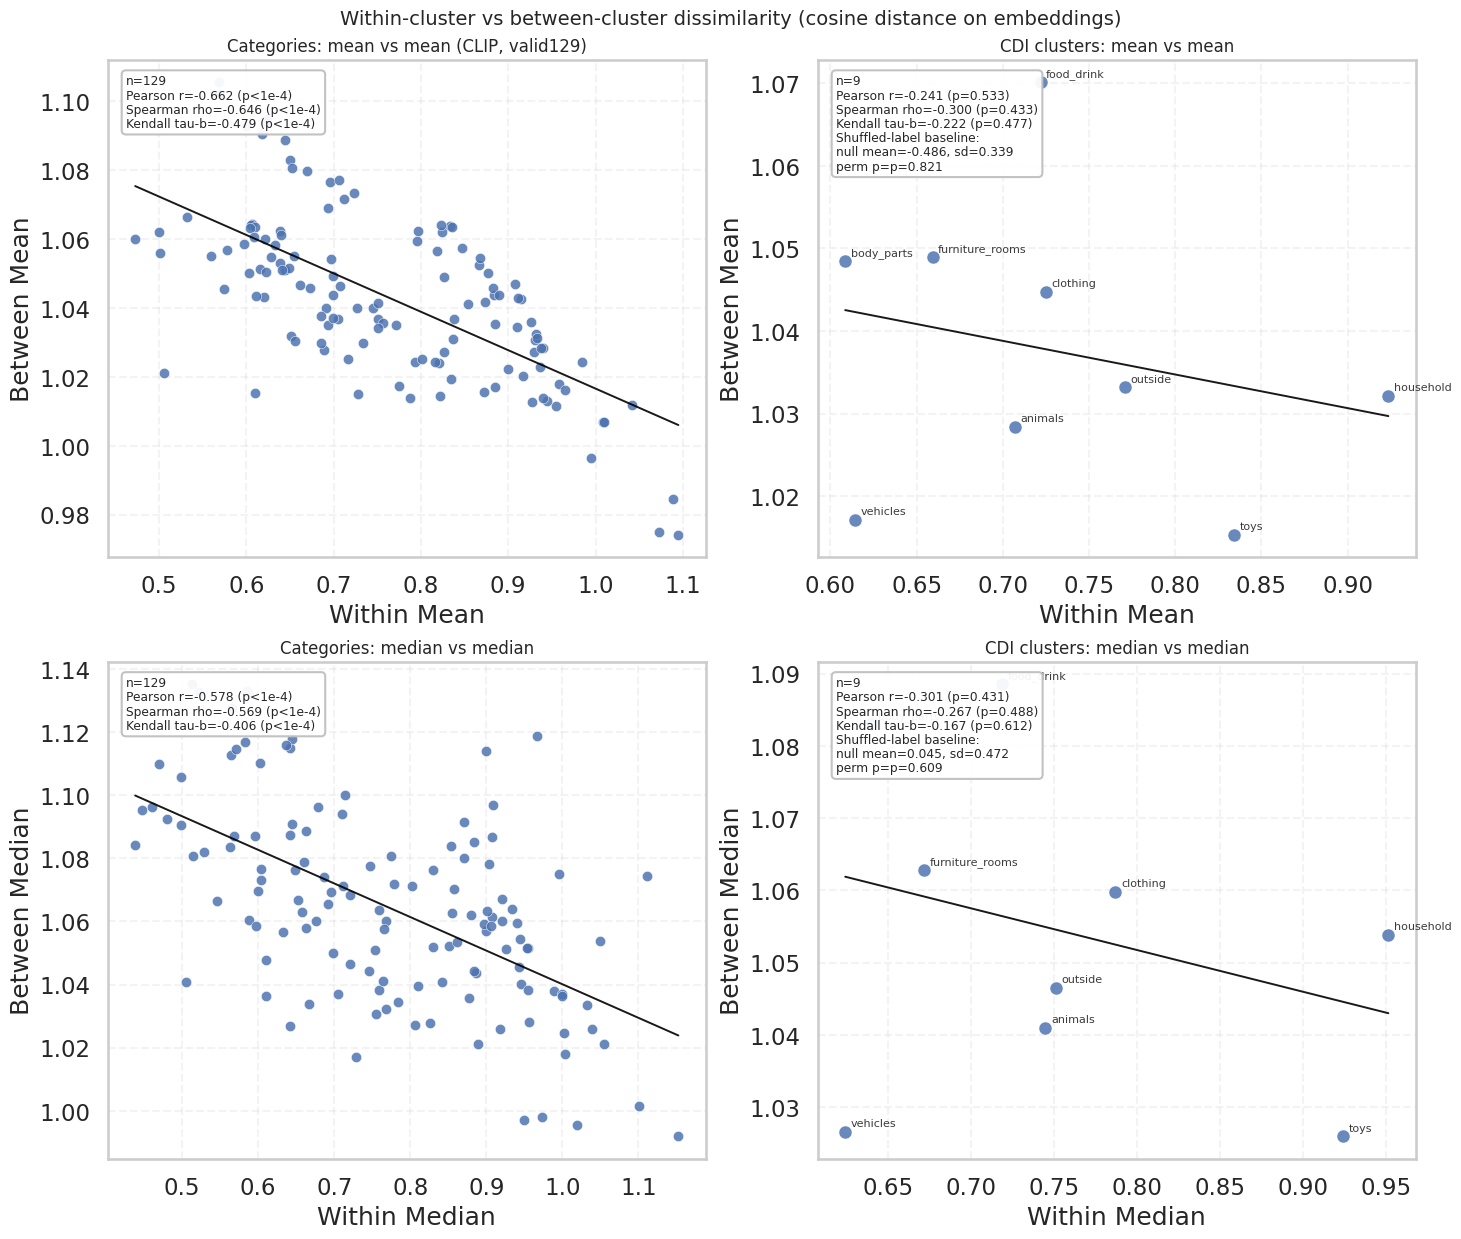

In [7]:
# Visualization helpers


def _format_p(p: float) -> str:
    if p is None or not np.isfinite(p):
        return 'p=—'
    if p < 1e-4:
        return 'p<1e-4'
    return f'p={p:.3g}'


def save_figure_png_pdf(fig, out_path, *, dpi: int = 200) -> None:
    """Write PNG and matching PDF alongside for publication-quality vector output."""
    out_path = Path(out_path)
    fig.savefig(out_path, dpi=dpi, bbox_inches='tight')
    fig.savefig(out_path.with_suffix('.pdf'), format='pdf', bbox_inches='tight')


def _corr_annotation_box(corr: dict, extra_lines: list[str] | None = None) -> str:
    n = int(corr.get('n', 0))
    if n < 3:
        text = f'n={n}\n(too few points for correlation)'
    else:
        text = (
            f"n={n}\n"
            f"Pearson r={corr['pearson_r']:.3f} ({_format_p(corr['pearson_p'])})\n"
            f"Spearman rho={corr['spearman_rho']:.3f} ({_format_p(corr['spearman_p'])})\n"
            f"Kendall tau-b={corr['kendall_tau_b']:.3f} ({_format_p(corr['kendall_p'])})"
        )
    if extra_lines:
        text += '\n' + '\n'.join(extra_lines)
    return text


def _format_shuffle_note(metric_key: str) -> list[str]:
    row = cluster_shuffle_baseline_df.loc[cluster_shuffle_baseline_df['metric'] == metric_key]
    if row.empty:
        return []
    row = row.iloc[0]
    return [
        'Shuffled-label baseline:',
        f"null mean={row['null_mean']:.3f}, sd={row['null_std']:.3f}",
        f"perm p={_format_p(row['p_perm_two_sided'])}",
    ]


def add_scatter_with_fit(
    ax,
    df: pd.DataFrame,
    x: str,
    y: str,
    title: str,
    *,
    corr: dict | None = None,
    label_col: str | None = None,
    point_size: int = 55,
    extra_lines: list[str] | None = None,
):
    cols = [x, y] + ([label_col] if label_col else [])
    plot_df = df[cols].dropna()
    sns.scatterplot(
        data=plot_df,
        x=x,
        y=y,
        ax=ax,
        s=point_size,
        alpha=0.84,
        color='#4C72B0',
        edgecolor='white',
        linewidth=0.4,
    )
    if len(plot_df) >= 2:
        sns.regplot(
            data=plot_df,
            x=x,
            y=y,
            ax=ax,
            scatter=False,
            ci=None,
            color='black',
            line_kws={'linewidth': 1.4, 'alpha': 0.9},
        )
    if label_col is not None:
        for _, row in plot_df.iterrows():
            ax.annotate(
                str(row[label_col]),
                (row[x], row[y]),
                xytext=(4, 4),
                textcoords='offset points',
                fontsize=8,
                alpha=0.9,
            )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(x.replace('_', ' ').title())
    ax.set_ylabel(y.replace('_', ' ').title())
    ax.grid(True, axis='both', linestyle='--', alpha=0.22)
    if corr is not None:
        ax.text(
            0.03,
            0.97,
            _corr_annotation_box(corr, extra_lines=extra_lines),
            transform=ax.transAxes,
            va='top',
            ha='left',
            fontsize=8.8,
            linespacing=1.12,
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='0.75', alpha=0.94),
        )


fig, axes = plt.subplots(2, 2, figsize=(14.5, 12), constrained_layout=True)

add_scatter_with_fit(
    axes[0, 0],
    category_df,
    'within_mean',
    'between_mean',
    f'Categories: mean vs mean ({EMBED_MODEL.upper()}, {CATEGORY_SET})',
    corr=category_corr_mean,
)
add_scatter_with_fit(
    axes[0, 1],
    cluster_df,
    'within_mean',
    'between_mean',
    'CDI clusters: mean vs mean',
    corr=cluster_corr_mean,
    label_col='cdi_semantic',
    point_size=88,
    extra_lines=_format_shuffle_note('mean_pearson_r'),
)
add_scatter_with_fit(
    axes[1, 0],
    category_df,
    'within_median',
    'between_median',
    'Categories: median vs median',
    corr=category_corr_median,
)
add_scatter_with_fit(
    axes[1, 1],
    cluster_df,
    'within_median',
    'between_median',
    'CDI clusters: median vs median',
    corr=cluster_corr_median,
    label_col='cdi_semantic',
    point_size=88,
    extra_lines=_format_shuffle_note('median_pearson_r'),
)

fig.suptitle(
    'Within-cluster vs between-cluster dissimilarity (cosine distance on embeddings)',
    fontsize=14,
    y=1.02,
)
plot_path = FIGURES_DIR / f'within_between_scatter_{EMBED_MODEL}_{OUTPUT_RUN_TAG}.png'
save_figure_png_pdf(fig, plot_path, dpi=220)
print(f'Saved: {plot_path} and {plot_path.with_suffix(".pdf")}')
plt.show()

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/within_between_cluster_bars_clip_valid129.png and /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/within_between_cluster_bars_clip_valid129.pdf


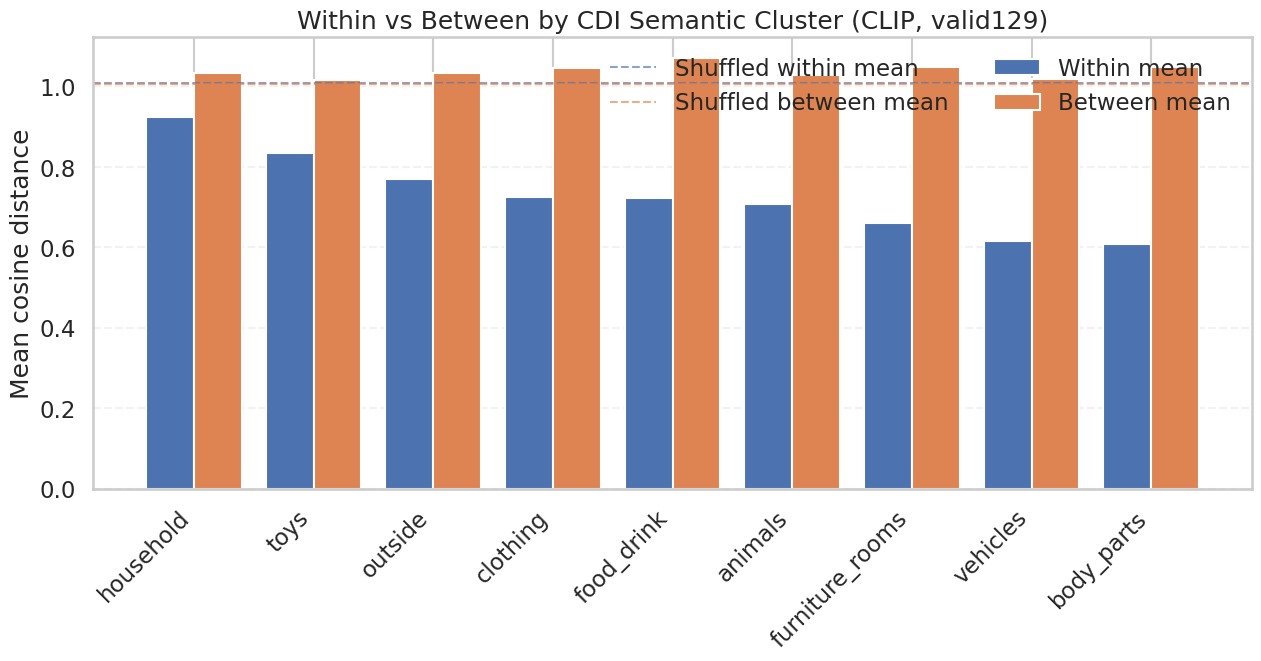

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/cluster_delta_vs_shuffle_null_mean_clip_valid129.png and /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/cluster_delta_vs_shuffle_null_mean_clip_valid129.pdf


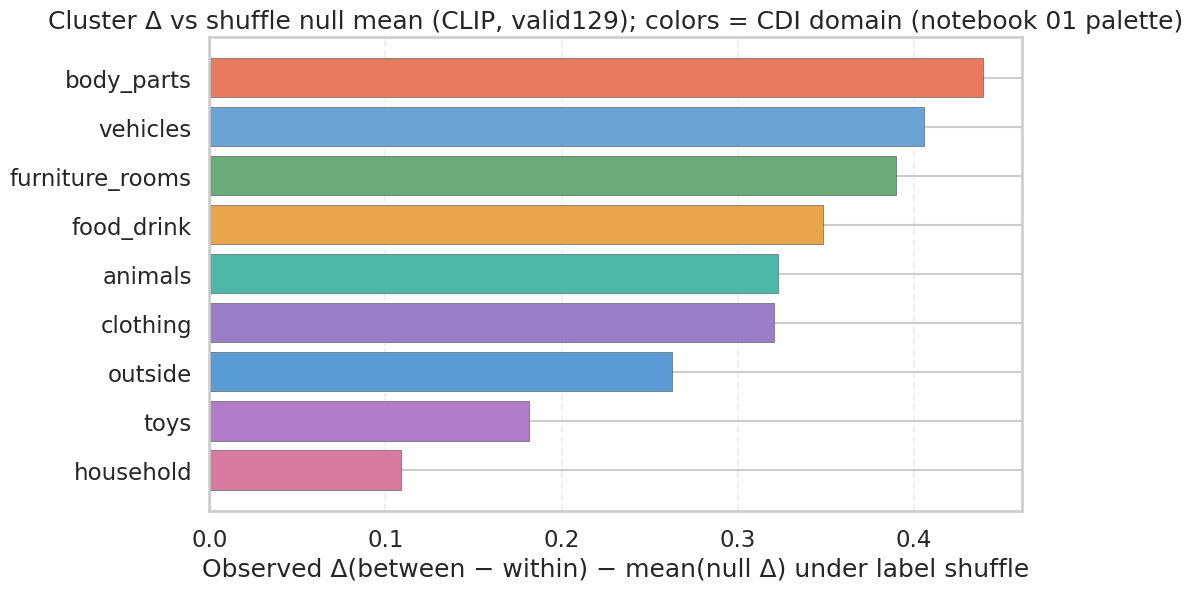

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/cluster_delta_shuffle_null_vs_observed_facets_clip_valid129.png and /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/cluster_delta_shuffle_null_vs_observed_facets_clip_valid129.pdf


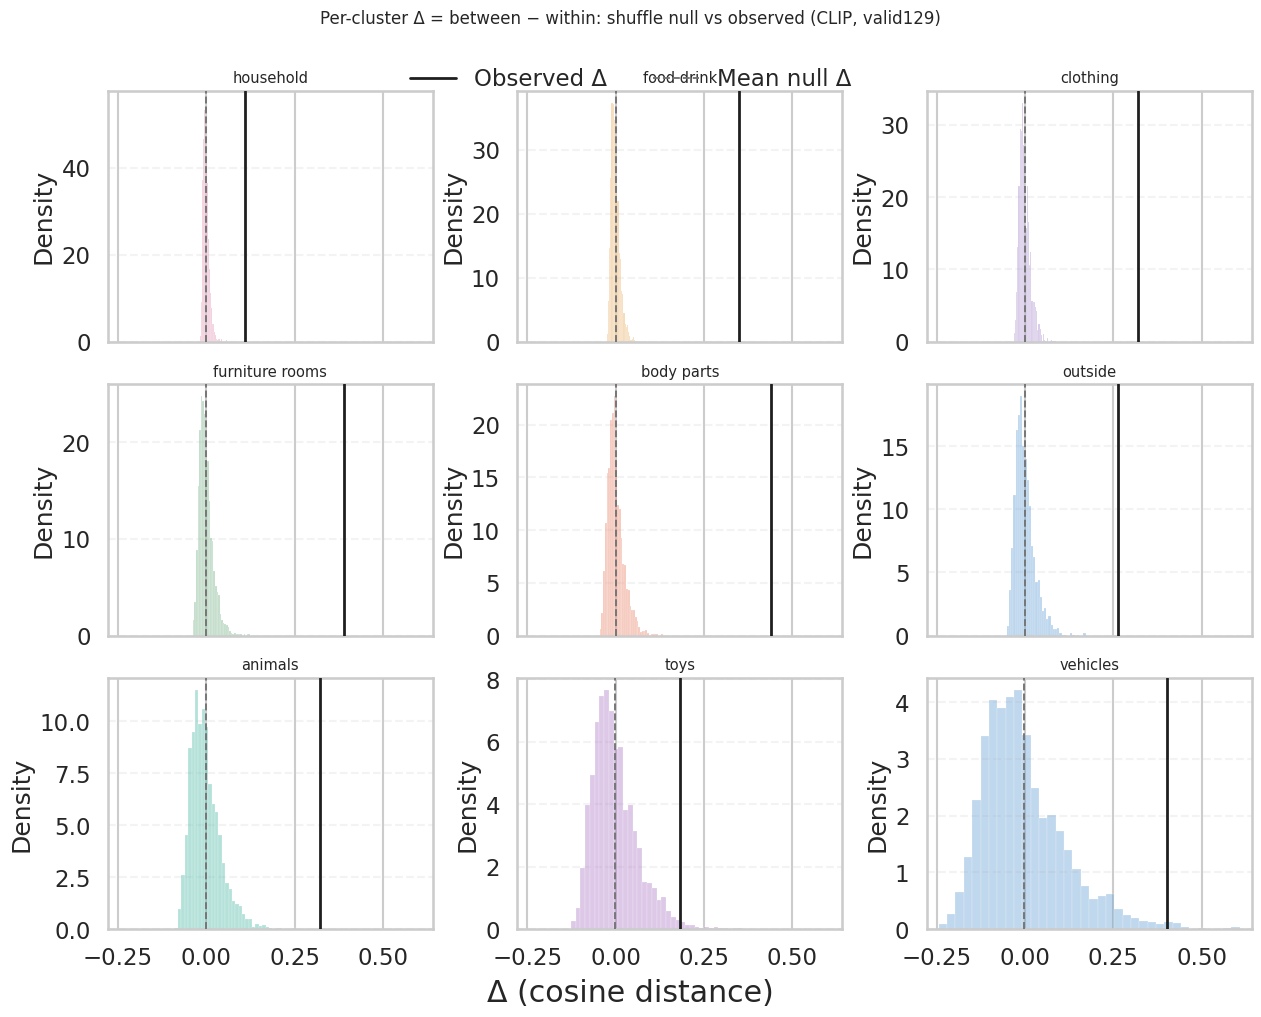

In [8]:
# Semantic-cluster summary plot
cluster_plot_df = cluster_df.sort_values('within_mean', ascending=False)
fig, ax = plt.subplots(figsize=(12.5, 6.5), constrained_layout=True)

x = np.arange(len(cluster_plot_df))
width = 0.4
ax.bar(x - width / 2, cluster_plot_df['within_mean'], width=width, label='Within mean', color='#4C72B0')
ax.bar(x + width / 2, cluster_plot_df['between_mean'], width=width, label='Between mean', color='#DD8452')

null_avg_within = cluster_shuffle_nulls['avg_within_mean']
null_avg_between = cluster_shuffle_nulls['avg_between_mean']
null_avg_within = null_avg_within[np.isfinite(null_avg_within)]
null_avg_between = null_avg_between[np.isfinite(null_avg_between)]

if null_avg_within.size:
    ax.axhline(np.mean(null_avg_within), linestyle='--', linewidth=1.5, color='#4C72B0', alpha=0.65, label='Shuffled within mean')
if null_avg_between.size:
    ax.axhline(np.mean(null_avg_between), linestyle='--', linewidth=1.5, color='#DD8452', alpha=0.65, label='Shuffled between mean')

ax.set_xticks(x)
ax.set_xticklabels(cluster_plot_df['cdi_semantic'], rotation=45, ha='right')
ax.set_ylabel('Mean cosine distance')
ax.set_title(f'Within vs Between by CDI Semantic Cluster ({EMBED_MODEL.upper()}, {CATEGORY_SET})')
ax.grid(True, axis='y', linestyle='--', alpha=0.25)
ax.legend(frameon=False, ncol=2)

bar_path = FIGURES_DIR / f'within_between_cluster_bars_{EMBED_MODEL}_{OUTPUT_RUN_TAG}.png'
save_figure_png_pdf(fig, bar_path, dpi=220)
print(f'Saved: {bar_path} and {bar_path.with_suffix(".pdf")}')
plt.show()

# Per-cluster Δ(between−within) vs mean of label-shuffle null (same n_perm/seed as shuffle baseline)
_delta_plot = cluster_delta_shuffle_summary_df.sort_values('obs_minus_null_mean', ascending=True).reset_index(drop=True)
fig_d, ax_d = plt.subplots(figsize=(10.2, 5.8), constrained_layout=True)
_y = np.arange(len(_delta_plot))
_bar_colors = [
    CDI_SEMANTIC_COLORS.get(str(s), CDI_SEMANTIC_COLORS['other']) for s in _delta_plot['cdi_semantic']
]
ax_d.barh(_y, _delta_plot['obs_minus_null_mean'], color=_bar_colors, edgecolor='0.35', linewidth=0.45)
ax_d.axvline(0.0, color='0.25', linewidth=1.0)
ax_d.set_yticks(_y)
ax_d.set_yticklabels(_delta_plot['cdi_semantic'])
ax_d.set_xlabel('Observed Δ(between − within) − mean(null Δ) under label shuffle')
ax_d.set_title(
    f'Cluster Δ vs shuffle null mean ({EMBED_MODEL.upper()}, {CATEGORY_SET}); '
    r'colors = CDI domain (notebook 01 palette)'
)
ax_d.grid(True, axis='x', linestyle='--', alpha=0.28)

delta_bar_path = FIGURES_DIR / f'cluster_delta_vs_shuffle_null_mean_{EMBED_MODEL}_{OUTPUT_RUN_TAG}.png'
save_figure_png_pdf(fig_d, delta_bar_path, dpi=220)
print(f'Saved: {delta_bar_path} and {delta_bar_path.with_suffix(".pdf")}')
plt.show()

# Facets: null Δ distribution (label shuffle) + observed Δ + mean null — same draws as above
_sum_ix = cluster_delta_shuffle_summary_df.set_index('cdi_semantic')
_dom_list = list(cluster_domain_order)
_n_dom = len(_dom_list)
_nc = 3
_nr = int(np.ceil(_n_dom / _nc))
fig_h, axes_h = plt.subplots(
    _nr,
    _nc,
    figsize=(12.5, 3.15 * _nr),
    sharex=True,
    sharey=False,
    constrained_layout=True,
)
_ax_flat = np.atleast_1d(axes_h).ravel()

_all_x = []
for _j, _d in enumerate(_dom_list):
    _col = cluster_delta_shuffle_null_mat[:, _j]
    _all_x.extend(_col[np.isfinite(_col)].tolist())
    _r = _sum_ix.loc[_d]
    _all_x.append(float(_r['observed_delta_between_minus_within']))
    _all_x.append(float(_r['null_mean_delta_between_minus_within']))
_xmin = float(np.nanmin(_all_x))
_xmax = float(np.nanmax(_all_x))
_pad = 0.04 * (_xmax - _xmin) if np.isfinite(_xmax - _xmin) and (_xmax > _xmin) else 0.02
_xlim = (_xmin - _pad, _xmax + _pad)

for _k in range(len(_ax_flat)):
    ax_h = _ax_flat[_k]
    if _k >= _n_dom:
        ax_h.set_visible(False)
        continue
    _d = _dom_list[_k]
    _j = _k
    _col = cluster_delta_shuffle_null_mat[:, _j]
    _col = _col[np.isfinite(_col)]
    _r = _sum_ix.loc[_d]
    _obs = float(_r['observed_delta_between_minus_within'])
    _nm = float(_r['null_mean_delta_between_minus_within'])
    _fill = CDI_SEMANTIC_COLORS.get(str(_d), CDI_SEMANTIC_COLORS['other'])
    if _col.size:
        ax_h.hist(
            _col,
            bins=36,
            density=True,
            color=_fill,
            alpha=0.42,
            edgecolor='white',
            linewidth=0.35,
        )
    ax_h.axvline(_obs, color='0.12', linewidth=2.0, zorder=4)
    ax_h.axvline(_nm, color='0.45', linewidth=1.35, linestyle='--', zorder=3)
    ax_h.set_title(str(_d).replace('_', ' '), fontsize=10.5)
    ax_h.set_ylabel('Density')
    ax_h.grid(True, axis='y', linestyle='--', alpha=0.22)
    ax_h.set_xlim(_xlim)

_handles = [
    plt.Line2D([0], [0], color='0.12', linewidth=2.0, label='Observed Δ'),
    plt.Line2D([0], [0], color='0.45', linewidth=1.35, linestyle='--', label='Mean null Δ'),
]
fig_h.legend(handles=_handles, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig_h.suptitle(
    f'Per-cluster Δ = between − within: shuffle null vs observed ({EMBED_MODEL.upper()}, {CATEGORY_SET})',
    fontsize=12,
    y=1.06,
)
if hasattr(fig_h, 'supxlabel'):
    fig_h.supxlabel('Δ (cosine distance)')
else:
    for _bk in range((_nr - 1) * _nc, _nr * _nc):
        if _bk < len(_ax_flat) and _ax_flat[_bk].get_visible():
            _ax_flat[_bk].set_xlabel('Δ (cosine distance)')

delta_hist_path = FIGURES_DIR / f'cluster_delta_shuffle_null_vs_observed_facets_{EMBED_MODEL}_{OUTPUT_RUN_TAG}.png'
save_figure_png_pdf(fig_h, delta_hist_path, dpi=220)
print(f'Saved: {delta_hist_path} and {delta_hist_path.with_suffix(".pdf")}')
plt.show()

In [9]:
# Save tabular outputs
run_tag = f'{EMBED_MODEL}_{OUTPUT_RUN_TAG}'

category_out = RESULTS_DIR / f'category_within_between_{run_tag}.csv'
cluster_out = RESULTS_DIR / f'cluster_within_between_{run_tag}.csv'
summary_out = RESULTS_DIR / f'correlation_summary_{run_tag}.csv'
shuffle_out = RESULTS_DIR / f'cluster_corr_shuffle_baseline_{run_tag}.csv'
shuffle_cluster_delta_out = RESULTS_DIR / f'cluster_delta_shuffle_vs_null_mean_{run_tag}.csv'

category_df.to_csv(category_out, index=False)
cluster_df.to_csv(cluster_out, index=False)

summary_df = pd.DataFrame(
    [
        {'level': 'category', 'stat': 'mean', **category_corr_mean},
        {'level': 'category', 'stat': 'median', **category_corr_median},
        {'level': 'cluster', 'stat': 'mean', **cluster_corr_mean},
        {'level': 'cluster', 'stat': 'median', **cluster_corr_median},
    ]
)
summary_df.to_csv(summary_out, index=False)
cluster_shuffle_baseline_df.to_csv(shuffle_out, index=False)
cluster_delta_shuffle_summary_df.to_csv(shuffle_cluster_delta_out, index=False)

display(summary_df)
display(cluster_shuffle_baseline_df)
print(f'Saved: {category_out}')
print(f'Saved: {cluster_out}')
print(f'Saved: {summary_out}')
print(f'Saved: {shuffle_out}')
print(f'Saved: {shuffle_cluster_delta_out}')

,level,stat,n,pearson_r,pearson_p,spearman_rho,spearman_p,kendall_tau_b,kendall_p
0,category,mean,129,-0.661815,1.356932e-17,-0.646243,1.331462e-16,-0.478682,8.560295e-16
1,category,median,129,-0.578291,7.140934e-13,-0.568723,2.049846e-12,-0.405669,9.213941e-12
2,cluster,mean,9,-0.240584,5.329144e-01,-0.300000,4.328453e-01,-0.222222,4.767086e-01
3,cluster,median,9,-0.301397,4.305994e-01,-0.266667,4.879223e-01,-0.166667,6.122024e-01


,metric,observed,null_mean,null_std,p_perm_two_sided,n_perm_valid
0,mean_pearson_r,-0.240584,-0.485531,0.338656,0.820590,2000
1,mean_spearman_rho,-0.300000,-0.525383,0.288450,0.801099,2000
2,mean_kendall_tau_b,-0.222222,-0.417750,0.241351,0.824588,2000
3,median_pearson_r,-0.301397,0.044927,0.472124,0.608696,2000
4,median_spearman_rho,-0.266667,0.071362,0.385325,0.552724,2000
5,median_kendall_tau_b,-0.166667,0.056764,0.301327,0.663668,2000


Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/results/category_within_between_clip_valid129.csv
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/results/cluster_within_between_clip_valid129.csv
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/results/correlation_summary_clip_valid129.csv
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/results/cluster_corr_shuffle_baseline_clip_valid129.csv
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/results/cluster_delta_shuffle_vs_null_mean_clip_valid129.csv


## BabyView vs THINGS: CDI superordinate cluster strength

This section tests whether CDI semantic clustering is stronger in BabyView than THINGS using matched category sets and matched embedding backbones (CLIP vs CLIP, DINOv3 vs DINO).

Embeddings match `03_bv_things_rdm_comparison.ipynb`: **exemplar-set** z-scored CSVs in `analysis/preprint-2026/exemplar_set_embeddings/{valid85|valid129}/` from notebooks **06** (BV) and **07** (THINGS). Output filenames still use `BV_THINGS_EMBED_THRESHOLD` (default `0.27`).

Primary effect-size metric:
- `cluster_strength_delta = mean_between - mean_within` (higher = stronger cluster separation)

Inference:
- Paired category bootstrap for `delta_BV - delta_THINGS` (95% CI)
- Label permutation test for model-specific deltas and cross-model delta difference

Outputs (this section and the following subsection): `bv_vs_things_cluster_strength_*.csv`, `bv_minus_things_delta_diff_ci_*.png`, per-cluster `bv_vs_things_cluster_strength_by_cdi_cluster_*.csv`, combined **`main_cdi_bin_bv_vs_things_shuffle_*` CSVs** (BV vs TH per bin + parallel shuffle *p* / effect vs null + FDR), `bv_vs_things_cluster_strength_rankcorr_*.csv`, `bv_vs_things_cluster_strength_paired_clusters_*.png`, `bv_vs_things_cluster_delta_bars_*.png`, and `bv_vs_things_cluster_delta_bars_2panel_*.png`, and **`main_cdi_bin_bv_vs_things_shuffle_table_*` PNG/PDF** (compact table of per-bin Δ, shuffle *p*, and FDR).

In [10]:
# THINGS/BV comparison helpers

def resolve_embedding_path(source: str, model: str) -> Path:
    """Match `03_bv_things_rdm_comparison.ipynb`: exemplar_set_embeddings/{bv|things}_* CSVs."""
    source = source.lower()
    model = model.lower()

    if model not in EMBEDDING_PAIRS:
        raise ValueError(f'Unsupported model: {model!r}')

    if source in {'babyview', 'bv'}:
        path = EMBEDDING_PAIRS[model]['bv']
    elif source in {'things', 'th'}:
        path = EMBEDDING_PAIRS[model]['things']
    else:
        raise ValueError(f'Unsupported source: {source!r}')

    if not path.exists():
        raise FileNotFoundError(f'Missing embeddings CSV ({model}/{source}): {path}')
    return path


def _candidate_semantic_order_csvs(model: str) -> list[Path]:
    stem = f'bv_things_rdm_order_bv_semantic_{model}_filtered-{THRESHOLD_TOKEN}_{CATEGORY_SET}.csv'
    run_root_name = 'supplemental_results_valid85cats' if CATEGORY_SET == 'valid85' else 'main_results_valid129cats'
    return [
        PREPRINT_DIR / run_root_name / 'results' / stem,
        RESULTS_DIR / stem,
    ]


def load_semantic_sorted_categories(model: str) -> list[str]:
    order_csv = None
    for p in _candidate_semantic_order_csvs(model):
        if p.exists():
            order_csv = p
            break
    if order_csv is None:
        tried = [str(p) for p in _candidate_semantic_order_csvs(model)]
        raise FileNotFoundError(
            f'Could not find saved semantic-sorted category order for model={model}. Tried: {tried}'
        )

    order_df = pd.read_csv(order_csv)
    required = {'position', 'category', 'cdi_semantic'}
    missing = required.difference(order_df.columns)
    if missing:
        raise ValueError(f'Order CSV missing required columns: {sorted(missing)} ({order_csv})')

    order_df = order_df.sort_values('position').reset_index(drop=True)
    cats = order_df['category'].astype(str).str.strip().str.lower().tolist()
    return cats


def paired_subset_for_model(model: str):
    bv_path = resolve_embedding_path('babyview', model)
    th_path = resolve_embedding_path('things', model)

    bv_categories_all, bv_emb_all = load_embedding_csv(bv_path)
    th_categories_all, th_emb_all = load_embedding_csv(th_path)

    included = set(load_included_categories(INCLUDED_CATEGORIES_TXT))
    ordered_from_original = load_semantic_sorted_categories(model)
    common_set = included.intersection(bv_categories_all).intersection(th_categories_all)
    common = [c for c in ordered_from_original if c in common_set]
    if len(common) < 5:
        raise ValueError(f'Not enough shared categories for model={model}: {len(common)}')
    if len(common) != len(common_set):
        missing_from_saved_order = sorted(common_set.difference(common))
        raise RuntimeError(
            f'Saved semantic order is missing categories for model={model}: {missing_from_saved_order[:10]}'
        )

    bv_cats, bv_emb = align_embeddings_to_categories(bv_categories_all, bv_emb_all, common)
    th_cats, th_emb = align_embeddings_to_categories(th_categories_all, th_emb_all, common)

    if bv_cats != th_cats:
        raise RuntimeError('Category alignment mismatch between BV and THINGS after alignment.')

    semantics = [load_cdi_semantic_map(CDI_SEMANTIC_CSV).get(c, 'other') for c in bv_cats]
    return bv_cats, semantics, bv_emb, th_emb, bv_path, th_path


def global_within_between_delta(rdm: np.ndarray, semantics: list[str]) -> dict[str, float]:
    sem = np.asarray(semantics)
    iu = np.triu_indices_from(rdm, k=1)
    vals = rdm[iu]
    same = sem[iu[0]] == sem[iu[1]]
    diff = ~same

    within = vals[same]
    between = vals[diff]
    within_mean = float(np.mean(within)) if within.size else np.nan
    between_mean = float(np.mean(between)) if between.size else np.nan

    return {
        'within_mean': within_mean,
        'between_mean': between_mean,
        'delta_between_minus_within': between_mean - within_mean,
        'n_within_pairs': int(within.size),
        'n_between_pairs': int(between.size),
    }


def bootstrap_delta_difference(
    bv_rdm: np.ndarray,
    th_rdm: np.ndarray,
    semantics: list[str],
    n_boot: int = 2000,
    seed: int = 2026,
) -> dict[str, float]:
    rng = np.random.default_rng(seed)
    n = len(semantics)
    sem = np.asarray(semantics)

    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        bv_sub = bv_rdm[np.ix_(idx, idx)]
        th_sub = th_rdm[np.ix_(idx, idx)]
        sem_sub = sem[idx].tolist()

        d_bv = global_within_between_delta(bv_sub, sem_sub)['delta_between_minus_within']
        d_th = global_within_between_delta(th_sub, sem_sub)['delta_between_minus_within']
        diffs.append(d_bv - d_th)

    diffs = np.asarray(diffs)
    return {
        'boot_mean': float(np.mean(diffs)),
        'boot_ci_low': float(np.quantile(diffs, 0.025)),
        'boot_ci_high': float(np.quantile(diffs, 0.975)),
        'boot_p_two_sided': float(2 * min(np.mean(diffs <= 0), np.mean(diffs >= 0))),
        'n_boot': int(n_boot),
    }


def permutation_p_value(
    rdm: np.ndarray,
    semantics: list[str],
    n_perm: int = 5000,
    seed: int = 2026,
) -> dict[str, float]:
    rng = np.random.default_rng(seed)
    observed = global_within_between_delta(rdm, semantics)['delta_between_minus_within']

    sem = np.asarray(semantics)
    perm_vals = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        perm_sem = rng.permutation(sem)
        perm_vals[i] = global_within_between_delta(rdm, perm_sem.tolist())['delta_between_minus_within']

    p = (np.sum(np.abs(perm_vals) >= abs(observed)) + 1) / (n_perm + 1)
    return {
        'observed_delta': float(observed),
        'perm_p_two_sided': float(p),
        'perm_mean': float(np.mean(perm_vals)),
        'perm_sd': float(np.std(perm_vals, ddof=1)),
        'n_perm': int(n_perm),
    }


def permutation_model_difference_p_value(
    bv_rdm: np.ndarray,
    th_rdm: np.ndarray,
    semantics: list[str],
    n_perm: int = 5000,
    seed: int = 2027,
) -> dict[str, float]:
    rng = np.random.default_rng(seed)

    obs_bv = global_within_between_delta(bv_rdm, semantics)['delta_between_minus_within']
    obs_th = global_within_between_delta(th_rdm, semantics)['delta_between_minus_within']
    observed_diff = obs_bv - obs_th

    sem = np.asarray(semantics)
    perm_diffs = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        perm_sem = rng.permutation(sem)
        d_bv = global_within_between_delta(bv_rdm, perm_sem.tolist())['delta_between_minus_within']
        d_th = global_within_between_delta(th_rdm, perm_sem.tolist())['delta_between_minus_within']
        perm_diffs[i] = d_bv - d_th

    p = (np.sum(np.abs(perm_diffs) >= abs(observed_diff)) + 1) / (n_perm + 1)
    return {
        'observed_diff': float(observed_diff),
        'perm_p_two_sided': float(p),
        'perm_mean': float(np.mean(perm_diffs)),
        'perm_sd': float(np.std(perm_diffs, ddof=1)),
        'n_perm': int(n_perm),
    }

In [11]:
# Within-vs-between rank correlations for each RDM separately (BabyView and THINGS; CLIP and DINOv3).
# For each (embedding model, source) we correlate `within_*` with `between_*` at category and CDI-cluster
# levels (Pearson / Spearman / Kendall tau-b). This is not BV–THINGS agreement; see `bv_vs_things_cluster_strength_rankcorr_*.csv` for that.

within_between_rank_rows: list[dict] = []
for model in ['clip', 'dinov3']:
    cats, sems, bv_emb, th_emb, _, _ = paired_subset_for_model(model)
    for source, emb in (('babyview', bv_emb), ('things', th_emb)):
        rdm = compute_rdm(emb)
        cat_df = category_within_between(cats, sems, rdm)
        cl_df = cluster_within_between(cats, sems, rdm)

        cat_mean_corr = safe_corr(cat_df['within_mean'].to_numpy(), cat_df['between_mean'].to_numpy())
        cat_med_corr = safe_corr(cat_df['within_median'].to_numpy(), cat_df['between_median'].to_numpy())
        cl_mean_corr = safe_corr(cl_df['within_mean'].to_numpy(), cl_df['between_mean'].to_numpy())
        cl_med_corr = safe_corr(cl_df['within_median'].to_numpy(), cl_df['between_median'].to_numpy())

        for level, stat, corr in (
            ('category', 'mean', cat_mean_corr),
            ('category', 'median', cat_med_corr),
            ('cluster', 'mean', cl_mean_corr),
            ('cluster', 'median', cl_med_corr),
        ):
            within_between_rank_rows.append({'model': model, 'source': source, 'level': level, 'stat': stat, **corr})

within_between_rank_df = (
    pd.DataFrame(within_between_rank_rows)
    .sort_values(['model', 'source', 'level', 'stat'])
    .reset_index(drop=True)
)
within_between_rank_out = RESULTS_DIR / f'within_between_rank_correlations_{OUTPUT_RUN_TAG}.csv'
within_between_rank_df.to_csv(within_between_rank_out, index=False)
display(within_between_rank_df)
print(f'Saved: {within_between_rank_out}')

,model,source,level,stat,n,pearson_r,pearson_p,spearman_rho,spearman_p,kendall_tau_b,kendall_p
0,clip,babyview,category,mean,129,-0.661815,1.356932e-17,-0.646243,1.331462e-16,-0.478682,8.560295e-16
1,clip,babyview,category,median,129,-0.578291,7.140934e-13,-0.568723,2.049846e-12,-0.405669,9.213941e-12
2,clip,babyview,cluster,mean,9,-0.240584,5.329144e-01,-0.300000,4.328453e-01,-0.222222,4.767086e-01
3,clip,babyview,cluster,median,9,-0.301397,4.305994e-01,-0.266667,4.879223e-01,-0.166667,6.122024e-01
4,clip,things,category,mean,129,-0.503616,1.175722e-09,-0.479947,8.650063e-09,-0.368459,5.894074e-10
5,clip,things,category,median,129,-0.336789,9.516738e-05,-0.326949,1.557263e-04,-0.223487,1.724705e-04
6,clip,things,cluster,mean,9,-0.263973,4.924951e-01,-0.200000,6.059013e-01,-0.111111,7.614142e-01
7,clip,things,cluster,median,9,-0.399822,2.863395e-01,-0.183333,6.368198e-01,-0.166667,6.122024e-01
8,dinov3,babyview,category,mean,129,-0.648577,9.536305e-17,-0.631384,1.044044e-15,-0.469961,2.804063e-15
9,dinov3,babyview,category,median,129,-0.562076,4.181035e-12,-0.550897,1.338735e-11,-0.408626,6.548960e-12


Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/results/within_between_rank_correlations_valid129.csv


In [12]:
# Run BV vs THINGS superordinate-cluster comparison
N_BOOT = int(os.environ.get('BV_CLUSTER_BOOTSTRAPS', '2000'))
N_PERM = int(os.environ.get('BV_CLUSTER_PERMUTATIONS', '5000'))
SEED = int(os.environ.get('BV_CLUSTER_SEED', '2026'))

models_to_run = ['clip', 'dinov3']
rows = []

for model in models_to_run:
    categories_m, semantics_m, bv_emb_m, th_emb_m, bv_path_m, th_path_m = paired_subset_for_model(model)

    bv_rdm_m = compute_rdm(bv_emb_m)
    th_rdm_m = compute_rdm(th_emb_m)

    bv_stats = global_within_between_delta(bv_rdm_m, semantics_m)
    th_stats = global_within_between_delta(th_rdm_m, semantics_m)

    boot = bootstrap_delta_difference(
        bv_rdm_m,
        th_rdm_m,
        semantics_m,
        n_boot=N_BOOT,
        seed=SEED,
    )
    perm_bv = permutation_p_value(
        bv_rdm_m,
        semantics_m,
        n_perm=N_PERM,
        seed=SEED,
    )
    perm_th = permutation_p_value(
        th_rdm_m,
        semantics_m,
        n_perm=N_PERM,
        seed=SEED + 1,
    )
    perm_diff = permutation_model_difference_p_value(
        bv_rdm_m,
        th_rdm_m,
        semantics_m,
        n_perm=N_PERM,
        seed=SEED + 2,
    )

    rows.append(
        {
            'model': model,
            'n_categories': len(categories_m),
            'bv_embedding_path': str(bv_path_m),
            'things_embedding_path': str(th_path_m),
            'bv_within_mean': bv_stats['within_mean'],
            'bv_between_mean': bv_stats['between_mean'],
            'bv_delta_between_minus_within': bv_stats['delta_between_minus_within'],
            'things_within_mean': th_stats['within_mean'],
            'things_between_mean': th_stats['between_mean'],
            'things_delta_between_minus_within': th_stats['delta_between_minus_within'],
            'delta_diff_bv_minus_things': bv_stats['delta_between_minus_within'] - th_stats['delta_between_minus_within'],
            'boot_ci_low': boot['boot_ci_low'],
            'boot_ci_high': boot['boot_ci_high'],
            'boot_p_two_sided': boot['boot_p_two_sided'],
            'perm_p_bv': perm_bv['perm_p_two_sided'],
            'perm_p_things': perm_th['perm_p_two_sided'],
            'perm_p_diff': perm_diff['perm_p_two_sided'],
            'n_boot': N_BOOT,
            'n_perm': N_PERM,
        }
    )

comparison_df = pd.DataFrame(rows).sort_values('model').reset_index(drop=True)
display(comparison_df)

for _, r in comparison_df.iterrows():
    direction = 'BabyView stronger' if r['delta_diff_bv_minus_things'] > 0 else 'THINGS stronger'
    print(
        f"[{r['model']}] {direction} | "
        f"delta_diff={r['delta_diff_bv_minus_things']:.4f}, "
        f"95% CI=[{r['boot_ci_low']:.4f}, {r['boot_ci_high']:.4f}], "
        f"perm_p_diff={r['perm_p_diff']:.4g}"
    )

,model,n_categories,bv_embedding_path,things_embedding_path,bv_within_mean,bv_between_mean,bv_delta_between_minus_within,things_within_mean,things_between_mean,things_delta_between_minus_within,delta_diff_bv_minus_things,boot_ci_low,boot_ci_high,boot_p_two_sided,perm_p_bv,perm_p_things,perm_p_diff,n_boot,n_perm
0,clip,129,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...,0.803735,1.043046,0.239311,0.851641,1.034758,0.183117,0.056194,0.022089,0.090258,0.0,0.0002,0.0002,0.0002,2000,5000
1,dinov3,129,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...,0.853173,1.034126,0.180953,0.949070,1.017900,0.068830,0.112122,0.073867,0.145344,0.0,0.0002,0.0002,0.0002,2000,5000


[clip] BabyView stronger | delta_diff=0.0562, 95% CI=[0.0221, 0.0903], perm_p_diff=0.0002
[dinov3] BabyView stronger | delta_diff=0.1121, 95% CI=[0.0739, 0.1453], perm_p_diff=0.0002


### BV vs THINGS cluster strength: variability across CDI semantic clusters

The global `mean(between) - mean(within)` metric in `comparison_df` averages **all category pairs** (off-diagonal) weighted by how many pairs fall into within- vs between-cluster bins.

**Note:** Rank correlations of **within vs between** (paired `within_mean` vs `between_mean`, and median counterparts, at category and CDI-cluster levels) for **each RDM separately** are in `within_between_rank_correlations_{valid129|valid85}.csv` (rows for `babyview` and `things`, each under `clip` and `dinov3`). The earlier `correlation_summary_{EMBED_MODEL}_*.csv` is the same statistic but only for the notebook-default `BV_EMBED_MODEL` on **BabyView** embeddings, to match the first-figure pipeline.

The table `bv_vs_things_cluster_strength_rankcorr_*.csv` and the following code implement **cross-model agreement**: for each embedding model, we correlate BabyView’s cluster-level `between_mean - within_mean` with THINGS’s cluster-level delta **across CDI clusters** (Spearman / Kendall). The same per-cluster BV and THINGS deltas are also plotted as **paired scatter** (`bv_vs_things_cluster_strength_paired_clusters_*.png`) and **grouped bar charts** (`bv_vs_things_cluster_delta_bars_*.png` and a two-model `bv_vs_things_cluster_delta_bars_2panel_*.png`).

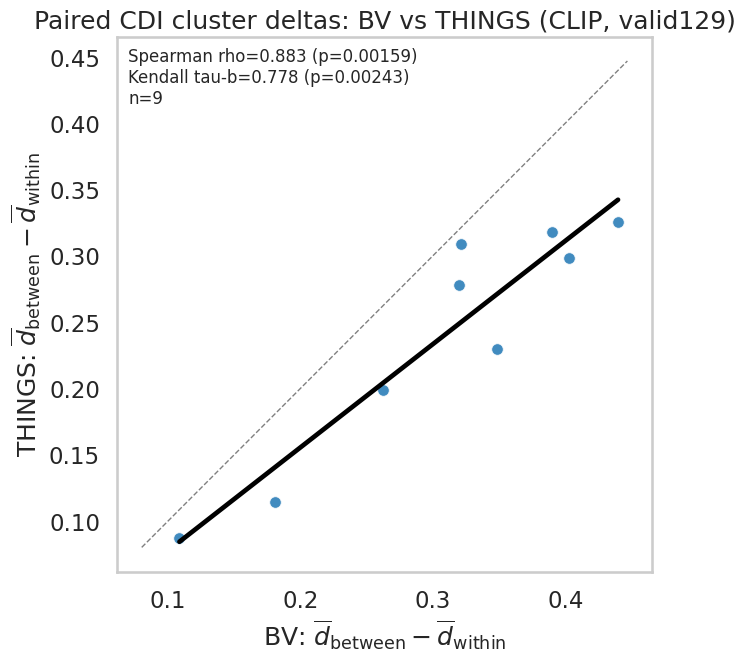

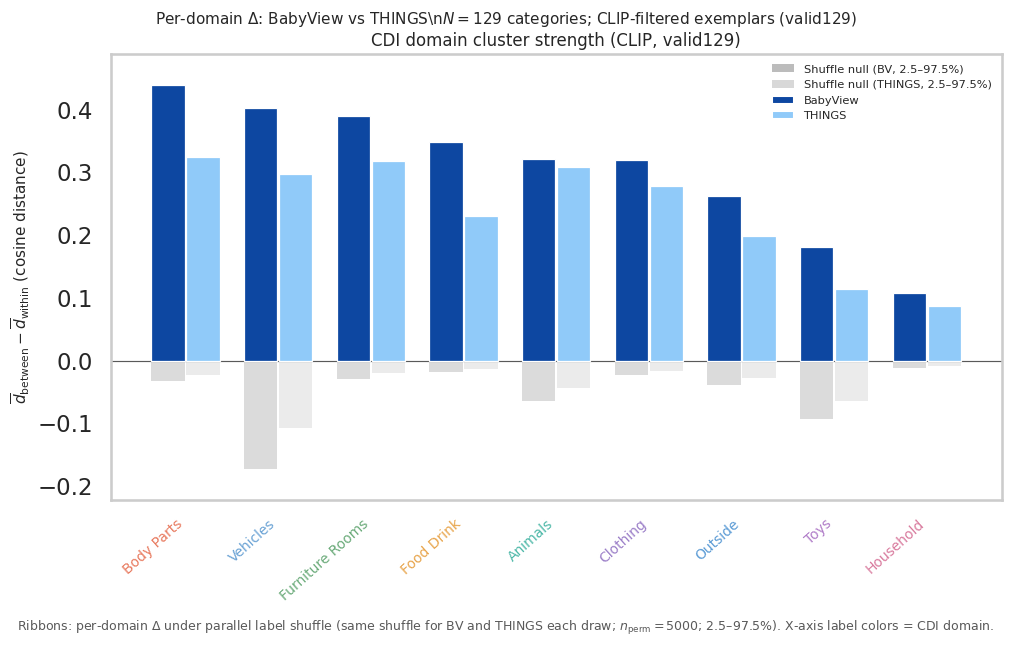

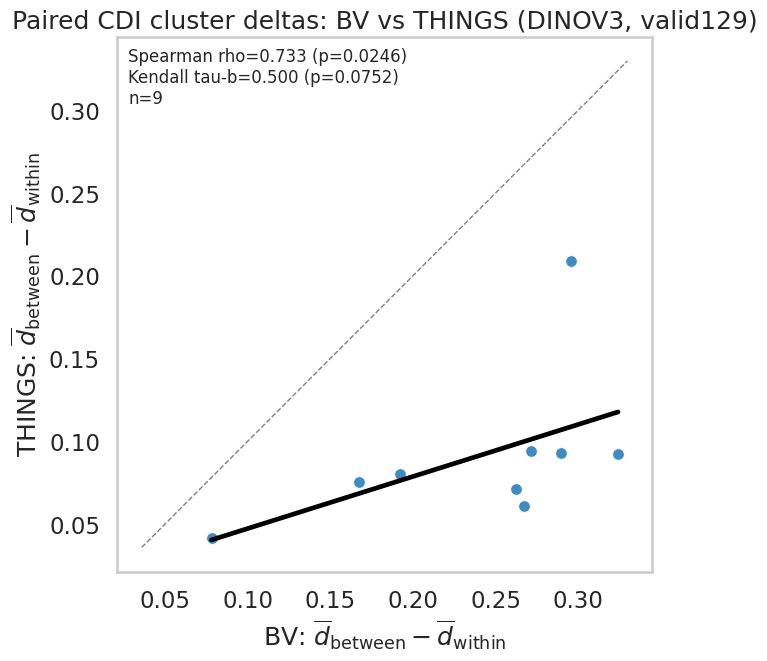

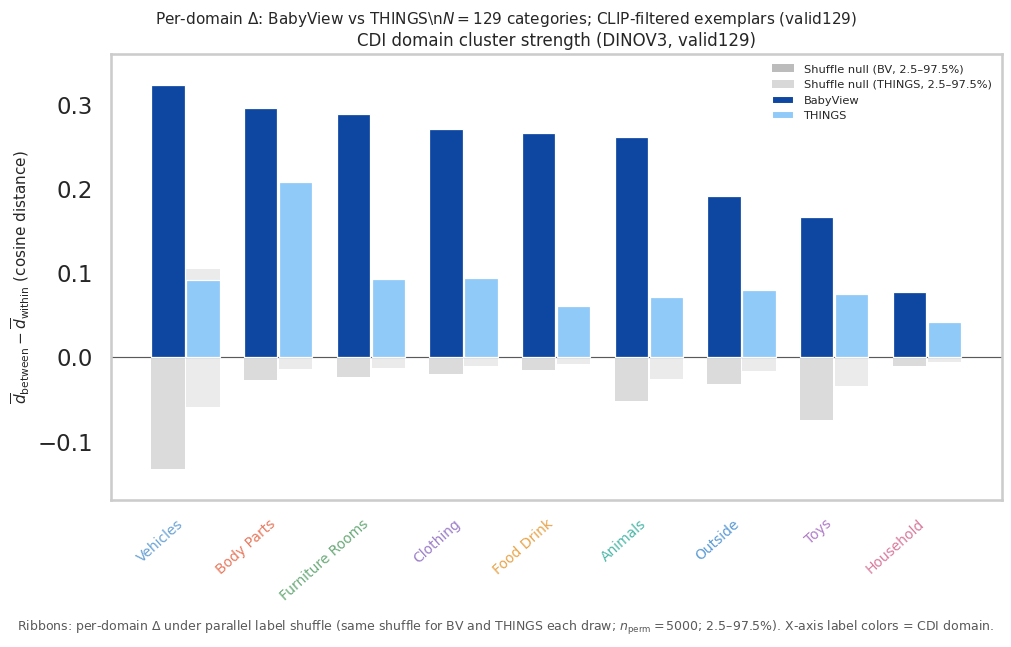

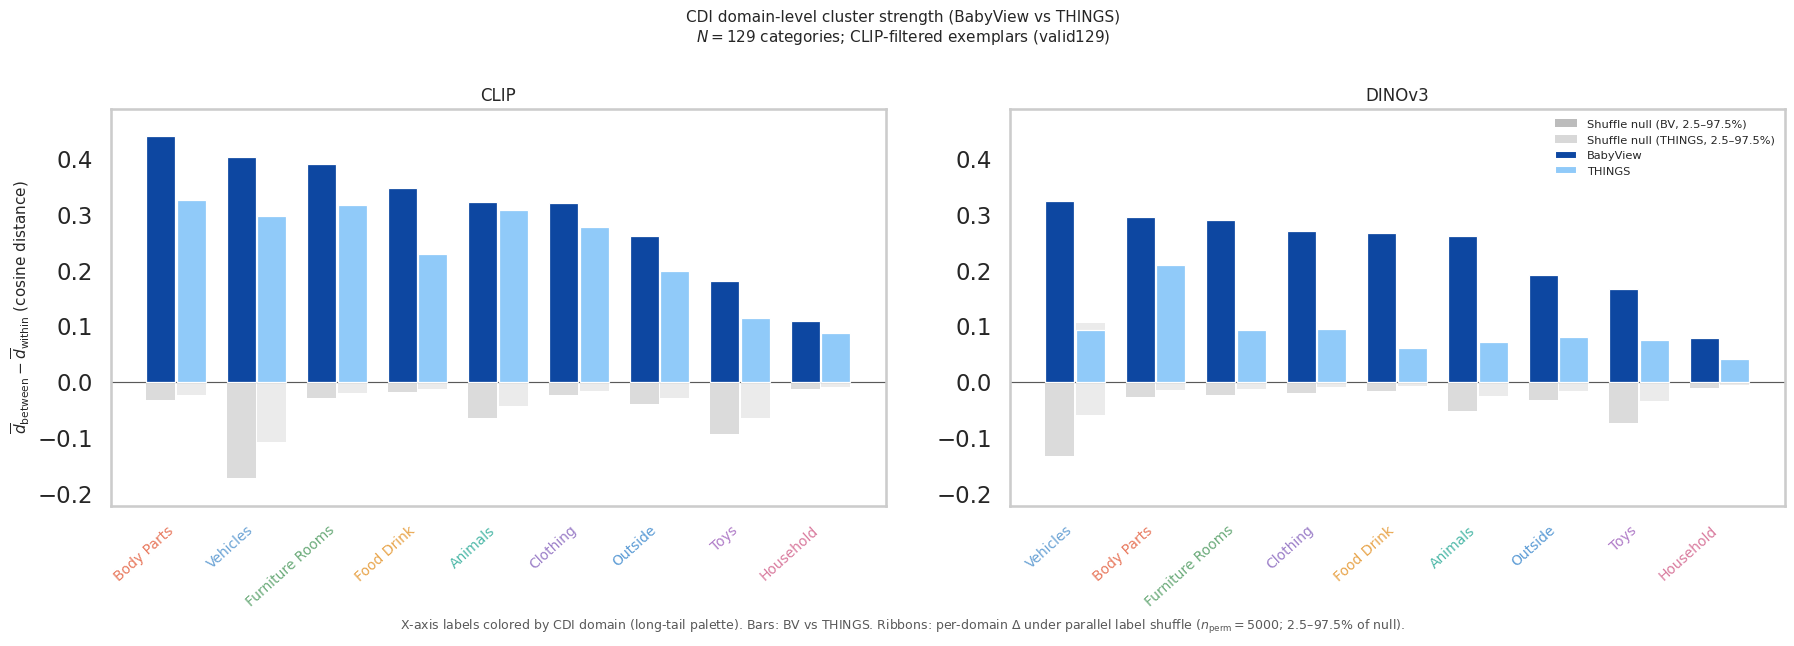

,model,n_clusters_used,spearman_rho,spearman_p,kendall_tau_b,kendall_p
0,clip,9,0.883333,0.001591,0.777778,0.002425
1,dinov3,9,0.733333,0.024554,0.500000,0.075176


Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/results/bv_vs_things_cluster_strength_rankcorr_valid129.csv
Saved plots:
 - /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/bv_vs_things_cluster_strength_paired_clusters_clip_valid129.png
 - /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/bv_vs_things_cluster_strength_paired_clusters_clip_valid129.pdf
 - /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/bv_vs_things_cluster_delta_bars_clip_valid129.png
 - /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/bv_vs_things_cluster_delta_bars_clip_valid129.pdf
 - /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_result

In [13]:
# Rank correlations between BV and THINGS at the CDI semantic-cluster level
from matplotlib.patches import Patch, Rectangle

_MODEL_PANEL_TITLES = {'clip': 'CLIP', 'dinov3': 'DINOv3'}


def cluster_delta_table(categories: list[str], rdm: np.ndarray, semantics: list[str]) -> pd.DataFrame:
    df = cluster_within_between(categories, semantics, rdm).set_index('cdi_semantic')
    df['delta_between_minus_within'] = df['between_mean'] - df['within_mean']
    return df[['n_categories', 'within_mean', 'between_mean', 'delta_between_minus_within']]


def _marginal_shuffle_quantile_bands(mat: np.ndarray) -> np.ndarray:
    """Rows = domains, cols = [q0.025, q0.5, q0.975]."""
    n_dom = mat.shape[1]
    q = np.full((n_dom, 3), np.nan, dtype=float)
    for j in range(n_dom):
        col = mat[:, j]
        col = col[np.isfinite(col)]
        if col.size:
            q[j, 0] = float(np.quantile(col, 0.025))
            q[j, 1] = float(np.quantile(col, 0.5))
            q[j, 2] = float(np.quantile(col, 0.975))
    return q


def _parallel_shuffle_domain_delta_mats(
    bv_rdm: np.ndarray,
    th_rdm: np.ndarray,
    categories: list[str],
    semantics: list[str],
    domain_order: list[str],
    *,
    n_perm: int,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """Full null matrices for BV and TH under parallel label shuffle (same labels each draw)."""
    sem_arr = np.asarray(semantics)
    n_dom = len(domain_order)
    mat_bv = np.full((n_perm, n_dom), np.nan, dtype=float)
    mat_th = np.full((n_perm, n_dom), np.nan, dtype=float)
    for i in range(n_perm):
        perm_sem = rng.permutation(sem_arr).tolist()
        tbl_bv = cluster_delta_table(categories, bv_rdm, perm_sem)
        tbl_th = cluster_delta_table(categories, th_rdm, perm_sem)
        for j, d in enumerate(domain_order):
            if d in tbl_bv.index:
                v = float(tbl_bv.loc[d, 'delta_between_minus_within'])
                if np.isfinite(v):
                    mat_bv[i, j] = v
            if d in tbl_th.index:
                v = float(tbl_th.loc[d, 'delta_between_minus_within'])
                if np.isfinite(v):
                    mat_th[i, j] = v
    return mat_bv, mat_th


def _perm_null_quantiles_by_domain_parallel(
    bv_rdm: np.ndarray,
    th_rdm: np.ndarray,
    categories: list[str],
    semantics: list[str],
    domain_order: list[str],
    *,
    n_perm: int,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """Parallel CDI label shuffle: same permuted labels for BV and THINGS each draw (matches global joint null).

    Returns two arrays of shape (n_domains, 3) with columns [q0.025, q0.5, q0.975] for BV and THINGS.
    """
    mat_bv, mat_th = _parallel_shuffle_domain_delta_mats(
        bv_rdm, th_rdm, categories, semantics, domain_order, n_perm=n_perm, rng=rng
    )
    return _marginal_shuffle_quantile_bands(mat_bv), _marginal_shuffle_quantile_bands(mat_th)


def _shuffle_vs_observed_per_domain_summary(
    null_mat: np.ndarray,
    obs_tbl: pd.DataFrame,
    domain_order: list[str],
    *,
    col_prefix: str,
) -> pd.DataFrame:
    """Per-domain two-sided label-shuffle inference for Δ = between_mean − within_mean."""

    def _perm_p_two_sided(obs: float, col: np.ndarray) -> float:
        valid = col[np.isfinite(col)]
        if valid.size == 0 or not np.isfinite(obs):
            return np.nan
        return float((np.sum(np.abs(valid) >= abs(obs)) + 1.0) / (valid.size + 1.0))

    rows = []
    for j, d in enumerate(domain_order):
        col = null_mat[:, j]
        valid = col[np.isfinite(col)]
        obs = (
            float(obs_tbl.loc[d, 'delta_between_minus_within'])
            if d in obs_tbl.index and np.isfinite(obs_tbl.loc[d, 'delta_between_minus_within'])
            else np.nan
        )
        nm = float(np.nanmean(col)) if valid.size else np.nan
        ns = float(np.nanstd(col, ddof=1)) if valid.size > 1 else np.nan
        z = (obs - nm) / ns if (np.isfinite(obs) and np.isfinite(ns) and ns > 0) else np.nan
        rows.append(
            {
                'cdi_semantic': d,
                f'{col_prefix}null_mean_delta': nm,
                f'{col_prefix}obs_minus_null_mean': obs - nm if np.isfinite(obs) and np.isfinite(nm) else np.nan,
                f'{col_prefix}null_std_delta': ns,
                f'{col_prefix}z_obs_minus_null_mean': z,
                f'{col_prefix}p_perm_two_sided': _perm_p_two_sided(obs, col),
                f'{col_prefix}n_perm_valid': int(valid.size),
            }
        )
    return pd.DataFrame(rows)


def _draw_perdomain_cluster_delta_bars(
    ax,
    bar_order: list[str],
    merged: pd.DataFrame,
    null_bv: np.ndarray,
    null_th: np.ndarray,
    *,
    title: str,
    show_ylabel: bool,
    show_legend: bool,
    y_limits: tuple[float, float] | None = None,
) -> None:
    """Bars = BV vs THINGS (neutral hues); x tick colors = CDI domain (notebook 01 palette); ribbons = parallel shuffle null."""
    # Bar fills fixed across domains; CDI category identity is shown via colored x-axis labels only.
    _bv_bar = '#0d47a1'
    _th_bar = '#90caf9'

    if 'cdi_semantic' not in merged.columns:
        raise ValueError('merged must include cdi_semantic column')
    merged_ix = merged.set_index('cdi_semantic')

    x = np.arange(len(bar_order))
    w = 0.36
    gap = 0.02
    bv_x = x - w / 2 - gap / 2
    th_x = x + w / 2 + gap / 2
    z_back = 0
    ax.grid(False)

    def _nice_label(s: str) -> str:
        return str(s).replace('_', ' ').title()

    ys: list[float] = []
    for k, sem in enumerate(bar_order):
        lo_b, hi_b = null_bv[k, 0], null_bv[k, 2]
        lo_t, hi_t = null_th[k, 0], null_th[k, 2]
        if np.isfinite(lo_b) and np.isfinite(hi_b):
            ax.add_patch(
                Rectangle(
                    (bv_x[k] - w / 2, lo_b),
                    w,
                    hi_b - lo_b,
                    facecolor='0.42',
                    edgecolor='none',
                    alpha=0.24,
                    zorder=z_back,
                )
            )
            ys.extend([lo_b, hi_b])
        if np.isfinite(lo_t) and np.isfinite(hi_t):
            ax.add_patch(
                Rectangle(
                    (th_x[k] - w / 2, lo_t),
                    w,
                    hi_t - lo_t,
                    facecolor='0.62',
                    edgecolor='none',
                    alpha=0.2,
                    zorder=z_back,
                )
            )
            ys.extend([lo_t, hi_t])

        row = merged_ix.loc[sem]
        db = float(row['delta_between_minus_within_bv'])
        dt = float(row['delta_between_minus_within_th'])
        ax.bar(bv_x[k], db, width=w, color=_bv_bar, edgecolor='white', linewidth=0.9, zorder=z_back + 2)
        ax.bar(
            th_x[k],
            dt,
            width=w,
            color=_th_bar,
            edgecolor='white',
            linewidth=0.9,
            zorder=z_back + 2,
        )
        ys.extend([db, dt])

    ax.axhline(0, color='0.35', linewidth=0.85, zorder=z_back)
    ax.set_xticks(x)
    tick_labels = [_nice_label(s) for s in bar_order]
    ax.set_xticklabels(tick_labels, rotation=42, ha='right', fontsize=10)
    for tick, sem in zip(ax.get_xticklabels(), bar_order):
        tick.set_color(CDI_SEMANTIC_COLORS.get(sem, CDI_SEMANTIC_COLORS['other']))

    if show_ylabel:
        ax.set_ylabel(
            r'$\overline{d}_{\mathrm{between}}-\overline{d}_{\mathrm{within}}$ (cosine distance)',
            fontsize=11,
        )
    ax.set_title(title, fontsize=12)
    y_min, y_max = min(ys), max(ys)
    pad = max(0.02, 0.08 * (y_max - y_min + 1e-9))
    auto_limits = (y_min - pad, y_max + pad)
    ax.set_ylim(*(y_limits if y_limits is not None else auto_limits))

    if show_legend:
        leg = [
            Patch(facecolor='0.42', alpha=0.45, edgecolor='none', label='Shuffle null (BV, 2.5–97.5%)'),
            Patch(facecolor='0.62', alpha=0.4, edgecolor='none', label='Shuffle null (THINGS, 2.5–97.5%)'),
            Patch(facecolor=_bv_bar, edgecolor='white', label='BabyView'),
            Patch(facecolor=_th_bar, edgecolor='white', label='THINGS'),
        ]
        ax.legend(handles=leg, frameon=False, fontsize=8.2, loc='upper right', ncol=1)


rank_rows = []
plot_paths = []
cluster_delta_plot_meta: dict[str, dict] = {}

for model in sorted(comparison_df['model'].unique()):
    cats, sems, bv_emb, th_emb, _, _ = paired_subset_for_model(model)

    bv_rdm = compute_rdm(bv_emb)
    th_rdm = compute_rdm(th_emb)

    bv_tbl = cluster_delta_table(cats, bv_rdm, sems)
    th_tbl = cluster_delta_table(cats, th_rdm, sems)

    merged = bv_tbl.join(th_tbl, lsuffix='_bv', rsuffix='_th', how='inner')
    merged = merged.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['delta_between_minus_within_bv', 'delta_between_minus_within_th']
    )

    m_bar = merged.reset_index()
    sem_col = 'cdi_semantic' if 'cdi_semantic' in m_bar.columns else m_bar.columns[0]
    plot_df_bar = m_bar[[sem_col, 'delta_between_minus_within_bv', 'delta_between_minus_within_th']].melt(
        id_vars=sem_col,
        value_vars=['delta_between_minus_within_bv', 'delta_between_minus_within_th'],
        var_name='source',
        value_name='delta',
    )
    plot_df_bar['source'] = plot_df_bar['source'].map(
        {
            'delta_between_minus_within_bv': 'BabyView',
            'delta_between_minus_within_th': 'THINGS',
        }
    )
    plot_df_bar = plot_df_bar.rename(columns={sem_col: 'cdi_semantic'})
    bar_order = (
        m_bar.sort_values('delta_between_minus_within_bv', ascending=False)[sem_col].astype(str).tolist()
    )

    rng_perm = np.random.default_rng(42)
    null_mat_bv, null_mat_th = _parallel_shuffle_domain_delta_mats(
        bv_rdm, th_rdm, cats, sems, bar_order, n_perm=N_PERM, rng=rng_perm
    )
    null_bv = _marginal_shuffle_quantile_bands(null_mat_bv)
    null_th = _marginal_shuffle_quantile_bands(null_mat_th)

    shuffle_bv = _shuffle_vs_observed_per_domain_summary(
        null_mat_bv, bv_tbl, bar_order, col_prefix='bv_shuffle_'
    )
    shuffle_th = _shuffle_vs_observed_per_domain_summary(
        null_mat_th, th_tbl, bar_order, col_prefix='th_shuffle_'
    )

    cluster_delta_plot_meta[model] = {
        'merged': merged.reset_index(),
        'order': bar_order,
        'null_bv': null_bv,
        'null_th': null_th,
    }

    x = merged['delta_between_minus_within_bv'].to_numpy(dtype=float)
    y = merged['delta_between_minus_within_th'].to_numpy(dtype=float)

    spear = spearmanr(x, y)
    kt = kendalltau(x, y)

    rank_rows.append(
        {
            'model': model,
            'n_clusters_used': int(len(merged)),
            'spearman_rho': float(spear.correlation),
            'spearman_p': float(spear.pvalue),
            'kendall_tau_b': float(kt.correlation),
            'kendall_p': float(kt.pvalue),
        }
    )

    out_tbl = RESULTS_DIR / f'bv_vs_things_cluster_strength_by_cdi_cluster_{model}_{OUTPUT_RUN_TAG}.csv'
    merged.reset_index().to_csv(out_tbl, index=False)

    main_wide = merged.reset_index().merge(shuffle_bv, on='cdi_semantic', how='left').merge(
        shuffle_th, on='cdi_semantic', how='left'
    )
    main_wide['obs_delta_diff_bv_minus_th'] = (
        main_wide['delta_between_minus_within_bv'] - main_wide['delta_between_minus_within_th']
    )
    try:
        from scipy.stats import false_discovery_control

        pb = main_wide['bv_shuffle_p_perm_two_sided'].to_numpy(dtype=float)
        pt = main_wide['th_shuffle_p_perm_two_sided'].to_numpy(dtype=float)
        main_wide['bv_shuffle_p_perm_fdr_bh'] = false_discovery_control(pb, method='bh')
        main_wide['th_shuffle_p_perm_fdr_bh'] = false_discovery_control(pt, method='bh')
    except Exception:
        main_wide['bv_shuffle_p_perm_fdr_bh'] = np.nan
        main_wide['th_shuffle_p_perm_fdr_bh'] = np.nan

    main_out = RESULTS_DIR / f'main_cdi_bin_bv_vs_things_shuffle_{model}_{OUTPUT_RUN_TAG}.csv'
    main_wide.to_csv(main_out, index=False)
    print(f'Saved: {main_out}')

    _ord_tbl = [d for d in bar_order if d in set(main_wide['cdi_semantic'].astype(str))]
    _twide = main_wide.set_index('cdi_semantic').loc[_ord_tbl].reset_index()

    def _fmt_p_tbl(v: float) -> str:
        if v is None or not np.isfinite(v):
            return '—'
        if v < 1e-4:
            return '<1e-4'
        return f'{v:.3g}'

    _rows_tbl = []
    for _, r in _twide.iterrows():
        _rows_tbl.append(
            [
                str(r['cdi_semantic']).replace('_', ' '),
                str(int(r['n_categories_bv'])),
                f"{float(r['delta_between_minus_within_bv']):.3f}",
                f"{float(r['delta_between_minus_within_th']):.3f}",
                f"{float(r['obs_delta_diff_bv_minus_th']):.3f}",
                _fmt_p_tbl(float(r['bv_shuffle_p_perm_two_sided'])),
                _fmt_p_tbl(float(r['th_shuffle_p_perm_two_sided'])),
                _fmt_p_tbl(float(r['bv_shuffle_p_perm_fdr_bh'])),
                _fmt_p_tbl(float(r['th_shuffle_p_perm_fdr_bh'])),
            ]
        )

    fig_t, ax_t = plt.subplots(figsize=(11.4, 0.65 + 0.36 * len(_rows_tbl)), constrained_layout=True)
    ax_t.axis('off')
    _hdr_tbl = [
        'CDI domain',
        'n',
        'Δ BV',
        'Δ TH',
        'BV − TH',
        'p BV shuf',
        'p TH shuf',
        'q BV FDR',
        'q TH FDR',
    ]
    tab = ax_t.table(cellText=_rows_tbl, colLabels=_hdr_tbl, loc='upper center', cellLoc='center')
    tab.auto_set_font_size(False)
    tab.set_fontsize(8.6)
    tab.scale(1.0, 1.88)
    for (kr, kc), cell in tab.get_celld().items():
        cell.set_edgecolor('0.72')
        if kr == 0:
            cell.set_facecolor('#e6e6e6')
            cell.get_text().set_weight('bold')
    fig_t.suptitle(
        f'Per-bin Δ (between − within) + parallel label-shuffle p and BH-FDR ({model.upper()}, {OUTPUT_RUN_TAG}; n_perm={N_PERM})',
        fontsize=10.8,
        y=0.995,
    )
    p_tbl = FIGURES_DIR / f'main_cdi_bin_bv_vs_things_shuffle_table_{model}_{OUTPUT_RUN_TAG}.png'
    save_figure_png_pdf(fig_t, p_tbl, dpi=220)
    plot_paths.append(str(p_tbl))
    plot_paths.append(str(p_tbl.with_suffix('.pdf')))
    plt.show()

    fig, ax = plt.subplots(figsize=(6.5, 6.5), constrained_layout=True)
    sns.scatterplot(x=x, y=y, ax=ax, s=70, alpha=0.85)
    sns.regplot(x=x, y=y, scatter=False, ci=None, color='black', ax=ax)
    ax.grid(False)

    lim_min = float(np.nanmin([np.nanmin(x), np.nanmin(y)]))
    lim_max = float(np.nanmax([np.nanmax(x), np.nanmax(y)]))
    pad = 0.02 * (lim_max - lim_min if np.isfinite(lim_max - lim_min) else 1.0)
    ax.plot([lim_min - pad, lim_max + pad], [lim_min - pad, lim_max + pad], linestyle='--', color='gray', linewidth=1)

    ax.set_title(f'Paired CDI cluster deltas: BV vs THINGS ({model.upper()}, {OUTPUT_RUN_TAG})')
    ax.set_xlabel(r'BV: $\overline{d}_{\mathrm{between}}-\overline{d}_{\mathrm{within}}$')
    ax.set_ylabel(r'THINGS: $\overline{d}_{\mathrm{between}}-\overline{d}_{\mathrm{within}}$')
    ax.text(
        0.02,
        0.98,
        f"Spearman rho={spear.correlation:.3f} (p={spear.pvalue:.3g})\nKendall tau-b={kt.correlation:.3f} (p={kt.pvalue:.3g})\nn={len(merged)}",
        transform=ax.transAxes,
        va='top',
        ha='left',
        fontsize=12,
    )

    p = FIGURES_DIR / f'bv_vs_things_cluster_strength_paired_clusters_{model}_{OUTPUT_RUN_TAG}.png'
    save_figure_png_pdf(fig, p, dpi=200)
    plot_paths.append(str(p))
    plot_paths.append(str(p.with_suffix('.pdf')))
    plt.show()

    w = max(10.0, 0.42 * len(bar_order))
    fig_b, ax_b = plt.subplots(figsize=(w, 5.8), constrained_layout=True)
    _draw_perdomain_cluster_delta_bars(
        ax_b,
        bar_order,
        merged.reset_index(),
        null_bv,
        null_th,
        title=f'CDI domain cluster strength ({model.upper()}, {OUTPUT_RUN_TAG})',
        show_ylabel=True,
        show_legend=True,
    )
    n_cat = len(cats)
    fig_b.suptitle(
        fr'Per-domain $\Delta$: BabyView vs THINGS\n$N={n_cat}$ categories; CLIP-filtered exemplars ({OUTPUT_RUN_TAG})',
        fontsize=11,
        y=1.03,
    )
    fig_b.text(
        0.5,
        -0.02,
        rf'Ribbons: per-domain $\Delta$ under parallel label shuffle (same shuffle for BV and THINGS each draw; '
        rf'$n_{{\mathrm{{perm}}}}={N_PERM}$; 2.5–97.5%). X-axis label colors = CDI domain.',
        fontsize=9,
        color='0.35',
        ha='center',
        va='top',
        transform=fig_b.transFigure,
    )
    p_bar = FIGURES_DIR / f'bv_vs_things_cluster_delta_bars_{model}_{OUTPUT_RUN_TAG}.png'
    save_figure_png_pdf(fig_b, p_bar, dpi=200)
    plot_paths.append(str(p_bar))
    plot_paths.append(str(p_bar.with_suffix('.pdf')))
    plt.show()

if cluster_delta_plot_meta:
    models_sorted = sorted(cluster_delta_plot_meta.keys())
    fig_c, axes_c = plt.subplots(1, 2, figsize=(18, 6.2))
    n_cat = int(comparison_df['n_categories'].iloc[0])

    # Enforce identical y-axis scaling across CLIP/DINO panels.
    shared_vals = []
    for model in models_sorted:
        meta = cluster_delta_plot_meta[model]
        mdf = meta['merged']
        shared_vals.extend(mdf['delta_between_minus_within_bv'].to_numpy(dtype=float).tolist())
        shared_vals.extend(mdf['delta_between_minus_within_th'].to_numpy(dtype=float).tolist())
        for arr in (meta['null_bv'], meta['null_th']):
            shared_vals.extend(arr[:, 0].tolist())
            shared_vals.extend(arr[:, 2].tolist())
    shared_vals = [v for v in shared_vals if np.isfinite(v)]
    if not shared_vals:
        shared_limits = None
    else:
        y0, y1 = float(min(shared_vals)), float(max(shared_vals))
        ypad = max(0.02, 0.08 * (y1 - y0 + 1e-9))
        shared_limits = (y0 - ypad, y1 + ypad)

    for ax, model in zip(axes_c, models_sorted):
        meta = cluster_delta_plot_meta[model]
        mdf = meta['merged']
        _draw_perdomain_cluster_delta_bars(
            ax,
            meta['order'],
            mdf,
            meta['null_bv'],
            meta['null_th'],
            title=_MODEL_PANEL_TITLES.get(model, model.upper()),
            show_ylabel=(model == models_sorted[0]),
            show_legend=(model == models_sorted[-1]),
            y_limits=shared_limits,
        )
    fig_c.suptitle(
        'CDI domain-level cluster strength (BabyView vs THINGS)\n'
        f'$N={n_cat}$ categories; CLIP-filtered exemplars ({OUTPUT_RUN_TAG})',
        fontsize=11,
        y=1.02,
    )
    fig_c.text(
        0.5,
        0.01,
        rf'X-axis labels colored by CDI domain (long-tail palette). Bars: BV vs THINGS. Ribbons: per-domain '
        rf'$\Delta$ under parallel label shuffle ($n_{{\mathrm{{perm}}}}={N_PERM}$; 2.5–97.5% of null).',
        fontsize=9,
        color='0.35',
        ha='center',
        va='bottom',
        transform=fig_c.transFigure,
    )
    fig_c.subplots_adjust(left=0.06, right=0.99, bottom=0.22, top=0.86, wspace=0.16)
    p_comb = FIGURES_DIR / f'bv_vs_things_cluster_delta_bars_2panel_{OUTPUT_RUN_TAG}.png'
    save_figure_png_pdf(fig_c, p_comb, dpi=220)
    plot_paths.append(str(p_comb))
    plot_paths.append(str(p_comb.with_suffix('.pdf')))
    plt.show()

rank_corr_df = pd.DataFrame(rank_rows).sort_values('model').reset_index(drop=True)
display(rank_corr_df)

rank_out = RESULTS_DIR / f'bv_vs_things_cluster_strength_rankcorr_{OUTPUT_RUN_TAG}.csv'
rank_corr_df.to_csv(rank_out, index=False)
print(f'Saved: {rank_out}')
print('Saved plots:')
for p in plot_paths:
    print(' -', p)



In [14]:
# Save comparison outputs
comparison_out = RESULTS_DIR / f'bv_vs_things_cluster_strength_{OUTPUT_RUN_TAG}.csv'
comparison_df.to_csv(comparison_out, index=False)
print(f'Saved: {comparison_out}')

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/results/bv_vs_things_cluster_strength_valid129.csv


Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/bv_minus_things_delta_diff_ci_valid129.png and /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/bv_minus_things_delta_diff_ci_valid129.pdf


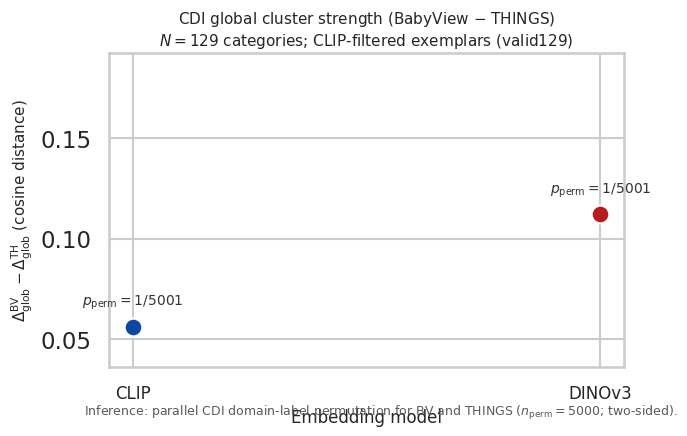

In [15]:
# Plot: Δ_glob^BV − Δ_glob^TH (publication style; primary inference = permutation p)
# Set BV_CLUSTER_PLOT_BOOTSTRAP=1 to overlay faint 95% bootstrap CIs (paired categories).
import os

_SHOW_BOOT = os.environ.get('BV_CLUSTER_PLOT_BOOTSTRAP', '0').strip().lower() in {'1', 'true', 'yes'}

_model_labels = {'clip': 'CLIP', 'dinov3': 'DINOv3'}
_colors = {'clip': '#0d47a1', 'dinov3': '#b71c1c'}

fig, ax = plt.subplots(figsize=(6.5, 4.25), constrained_layout=True)
fig.patch.set_facecolor('white')

x = np.arange(len(comparison_df))
y = comparison_df['delta_diff_bv_minus_things'].to_numpy()
models = comparison_df['model'].astype(str).tolist()

for i, m in enumerate(models):
    ax.scatter(
        [i],
        [y[i]],
        s=165,
        zorder=3,
        color=_colors.get(m, '#424242'),
        edgecolors='white',
        linewidths=1.6,
    )

if _SHOW_BOOT:
    err_low = y - comparison_df['boot_ci_low'].to_numpy()
    err_high = comparison_df['boot_ci_high'].to_numpy() - y
    ax.errorbar(
        x,
        y,
        yerr=np.vstack([err_low, err_high]),
        fmt='none',
        ecolor='0.4',
        elinewidth=1.1,
        capsize=4,
        capthick=1.1,
        zorder=2,
        alpha=0.55,
        label='95% bootstrap CI',
    )

ax.axhline(0.0, color='0.35', linewidth=0.9, linestyle='--', zorder=1)
ax.set_xticks(x)
ax.set_xticklabels([_model_labels.get(m, m.upper()) for m in models], fontsize=12)
ax.set_xlabel('Embedding model', fontsize=12)
ax.set_ylabel(
    r'$\Delta_{\mathrm{glob}}^{\mathrm{BV}}-\Delta_{\mathrm{glob}}^{\mathrm{TH}}$ (cosine distance)',
    fontsize=11,
)

n_cat = int(comparison_df['n_categories'].iloc[0])
ax.set_title(
    'CDI global cluster strength (BabyView $-$ THINGS)\n'
    f'$N={n_cat}$ categories; CLIP-filtered exemplars ({CATEGORY_SET})',
    fontsize=11,
)

ymax = float(np.nanmax(y)) if len(y) else 0.0
ymin = float(np.nanmin(y)) if len(y) else 0.0
pad = max(0.02, 0.12 * (ymax - ymin + 1e-9))
ax.set_ylim(ymin - pad, ymax + pad + 0.06)

for i, (_, row) in enumerate(comparison_df.iterrows()):
    pval = float(row['perm_p_diff'])
    if abs(pval - (1.0 / 5001.0)) < 5e-6 or pval <= 0.00021:
        ptxt = r'$p_{\mathrm{perm}}=1/5001$'
    else:
        ptxt = rf'$p_{{\mathrm{{perm}}}}={pval:.3g}$'
    ax.annotate(
        ptxt,
        xy=(i, y[i]),
        xytext=(0, 11),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=10,
        color='0.2',
    )

fig.text(
    0.12,
    0.02,
    'Inference: parallel CDI domain-label permutation for BV and THINGS '
    r'($n_{\mathrm{perm}}=5000$; two-sided).',
    fontsize=9,
    color='0.35',
    ha='left',
    va='bottom',
)

if _SHOW_BOOT:
    ax.legend(frameon=False, loc='upper right', fontsize=9)

diff_ci_path = FIGURES_DIR / f'bv_minus_things_delta_diff_ci_{OUTPUT_RUN_TAG}.png'
save_figure_png_pdf(fig, diff_ci_path, dpi=220)
print(f'Saved: {diff_ci_path} and {diff_ci_path.with_suffix(".pdf")}')
plt.show()

## Binary CDI-cluster template RDMs *(commented out — not used in current preprint)*


`template_sim`: within=1, between=0  
`template_dis`: within=0, between=1

This section constructs binary semantic template matrices for BabyView and THINGS using each model's aligned category list:
- `1` if two categories share the same CDI semantic cluster
- `0` otherwise

Diagonal is set to `np.nan` by default for visualization/analysis convenience.

In [ ]:
# # Helper: build binary CDI template RDM

# def build_binary_cdi_template_rdm(
#     semantics: list[str],
#     diagonal_value: float = np.nan,
# ) -> np.ndarray:
#     sem = np.asarray(semantics)
#     template = (sem[:, None] == sem[None, :]).astype(float)
#     np.fill_diagonal(template, diagonal_value)
#     return template

In [ ]:
# # Construct binary template RDMs for each source/model using aligned categories
# records = []

# for model in ['clip', 'dinov3']:
#     cats, sems, bv_emb, th_emb, bv_path, th_path = paired_subset_for_model(model)

#     # Same category order for BV and THINGS by construction.
#     bv_template = build_binary_cdi_template_rdm(sems, diagonal_value=np.nan)
#     th_template = build_binary_cdi_template_rdm(sems, diagonal_value=np.nan)

#     # Save matrices and category metadata.
#     bv_out = RESULTS_DIR / f'binary_cdi_template_rdm_babyview_{model}_{OUTPUT_RUN_TAG}.csv'
#     th_out = RESULTS_DIR / f'binary_cdi_template_rdm_things_{model}_{OUTPUT_RUN_TAG}.csv'
#     meta_out = RESULTS_DIR / f'binary_cdi_template_categories_{model}_{OUTPUT_RUN_TAG}.csv'

#     pd.DataFrame(bv_template, index=cats, columns=cats).to_csv(bv_out)
#     pd.DataFrame(th_template, index=cats, columns=cats).to_csv(th_out)
#     pd.DataFrame({'position': np.arange(len(cats)), 'category': cats, 'cdi_semantic': sems}).to_csv(meta_out, index=False)

#     n = len(cats)
#     total_offdiag = n * (n - 1)
#     ones_offdiag = int(np.nansum(np.nan_to_num(bv_template, nan=0.0)))
#     zeros_offdiag = int(total_offdiag - ones_offdiag)

#     records.append(
#         {
#             'model': model,
#             'n_categories': n,
#             'offdiag_ones_within': ones_offdiag,
#             'offdiag_zeros_between': zeros_offdiag,
#             'babyview_template_csv': str(bv_out),
#             'things_template_csv': str(th_out),
#             'category_semantic_csv': str(meta_out),
#         }
#     )

# binary_template_summary_df = pd.DataFrame(records)
# display(binary_template_summary_df)

,model,n_categories,offdiag_ones_within,offdiag_zeros_between,babyview_template_csv,things_template_csv,category_semantic_csv
0,clip,129,2478,14034,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...
1,dinov3,129,2478,14034,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...,/home/j7yang/babyview-projects/vss2026/object-...


Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/binary_cdi_template_rdm_heatmap_babyview_vs_things_clip_valid129.png and /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/binary_cdi_template_rdm_heatmap_babyview_vs_things_clip_valid129.pdf


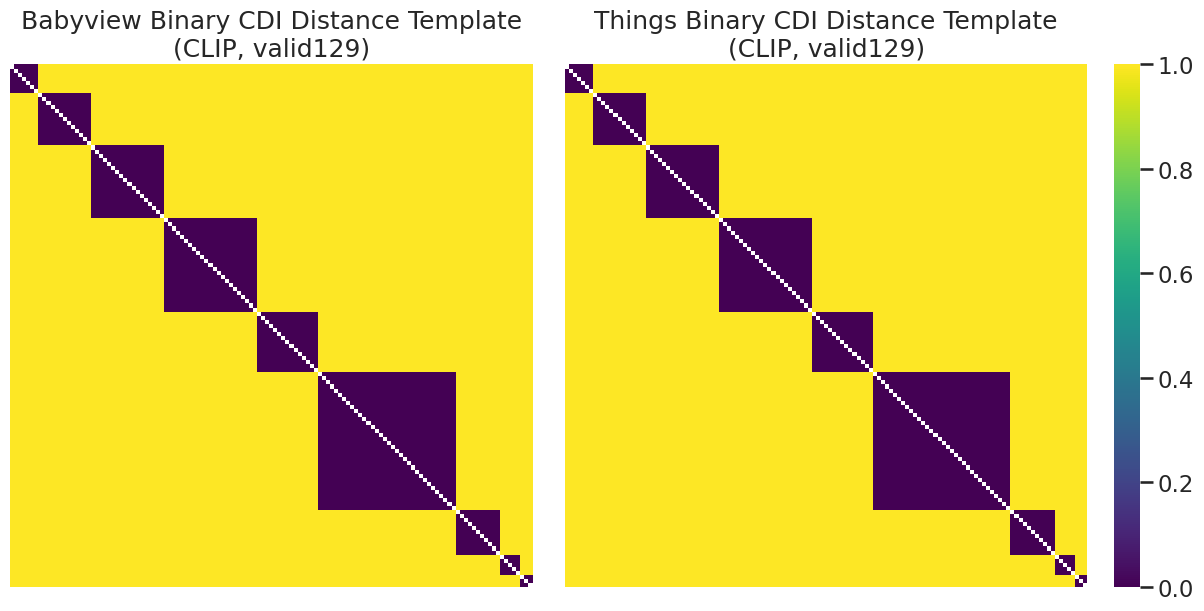

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/binary_cdi_template_rdm_heatmap_babyview_vs_things_dinov3_valid129.png and /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/binary_cdi_template_rdm_heatmap_babyview_vs_things_dinov3_valid129.pdf


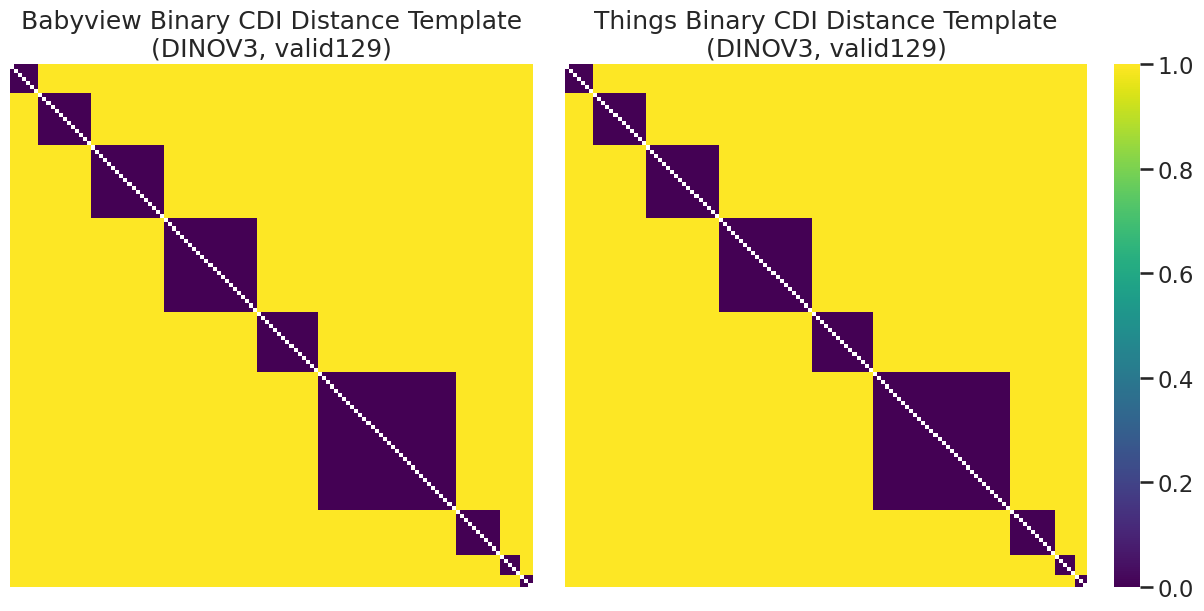

In [ ]:
# # Visual sanity-check of binary template DISTANCE RDMs (BabyView + THINGS)
# for model in ['clip', 'dinov3']:
#     cats, sems, _, _, _, _ = paired_subset_for_model(model)
#     template_sim = build_binary_cdi_template_rdm(sems, diagonal_value=np.nan)
#     template_dis = 1.0 - template_sim  # within=0, between=1

#     # Plot each source explicitly so BabyView and THINGS are both visible in outputs.
#     fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
#     for ax, source in zip(axes, ['babyview', 'things']):
#         sns.heatmap(
#             template_dis,
#             ax=ax,
#             cmap='viridis',
#             vmin=0,
#             vmax=1,
#             cbar=(source == 'things'),
#             square=True,
#             xticklabels=False,
#             yticklabels=False,
#         )
#         ax.set_title(f'{source.title()} Binary CDI Distance Template\n({model.upper()}, {CATEGORY_SET})')

#     fig_out = FIGURES_DIR / f'binary_cdi_template_rdm_heatmap_babyview_vs_things_{model}_{OUTPUT_RUN_TAG}.png'
#     save_figure_png_pdf(fig, fig_out, dpi=200)
#     print(f'Saved: {fig_out} and {fig_out.with_suffix(".pdf")}')
#     plt.show()

## Correlate binary CDI distance template *(commented out — not used in current preprint)*


This section quantifies how well the binary CDI **distance** structure (`within=0`, `between=1`) aligns with each source's real-valued cosine-distance RDM.

For each model (`clip`, `dinov3`) and source (`babyview`, `things`), we compute upper-triangle correlations on off-diagonal pairs:
- **Primary**: Spearman `rho` (rank-based; typically more stable for heavy-tailed distance matrices)
- **Secondary**: Pearson `r` (kept in the CSV for reference)

The correlation table is written when the analysis cell runs: `results/binary_template_vs_real_rdm_correlations_{valid129|valid85}.csv`. Figures: distance-template heatmaps, `binary_template_vs_real_rdm_spearman_*.png`, and `scatter_template_vs_rdm_{babyview,things}_{clip,dinov3}_*.png`.

In [ ]:
# # Helpers for RDM-template correlation

# def vectorize_upper_triangle_masked(mat: np.ndarray) -> np.ndarray:
#     """Backward-compatible helper used by downstream scatter cells."""
#     iu = np.triu_indices_from(mat, k=1)
#     vec = mat[iu]
#     return vec[np.isfinite(vec)]


# def correlate_template_with_rdm(template_dis: np.ndarray, rdm: np.ndarray) -> dict[str, float]:
#     """Correlate binary CDI distance template (within=0, between=1) with real RDM."""
#     if template_dis.shape != rdm.shape:
#         raise ValueError(f'Shape mismatch: template {template_dis.shape} vs rdm {rdm.shape}')

#     iu = np.triu_indices_from(template_dis, k=1)
#     t_dis_raw = template_dis[iu]
#     r_raw = rdm[iu]

#     # Keep only pairs valid in both vectors so elementwise correspondence is guaranteed.
#     mask = np.isfinite(t_dis_raw) & np.isfinite(r_raw)
#     t_dis = t_dis_raw[mask]
#     r = r_raw[mask]

#     # Guardrail: enforce expected binary distance convention.
#     uniq = np.unique(t_dis)
#     if not np.all(np.isin(uniq, [0.0, 1.0])):
#         raise ValueError(f'Unexpected template distance values: {uniq}')

#     corr_dis = safe_corr(t_dis, r)

#     return {
#         'n_pairs': int(mask.sum()),
#         'pearson_r_template_dissim_vs_rdm': corr_dis['pearson_r'],
#         'pearson_p_template_dissim_vs_rdm': corr_dis['pearson_p'],
#         'spearman_rho_template_dissim_vs_rdm': corr_dis['spearman_rho'],
#         'spearman_p_template_dissim_vs_rdm': corr_dis['spearman_p'],
#     }

In [ ]:
# # Run binary-distance-template vs real-RDM correlations
# corr_rows = []

# for model in ['clip', 'dinov3']:
#     cats, sems, bv_emb, th_emb, _, _ = paired_subset_for_model(model)

#     bv_rdm = compute_rdm(bv_emb)
#     th_rdm = compute_rdm(th_emb)

#     template_sim = build_binary_cdi_template_rdm(sems, diagonal_value=np.nan)
#     template_dis = 1.0 - template_sim

#     bv_corr = correlate_template_with_rdm(template_dis, bv_rdm)
#     th_corr = correlate_template_with_rdm(template_dis, th_rdm)

#     corr_rows.append({'model': model, 'source': 'babyview', **bv_corr})
#     corr_rows.append({'model': model, 'source': 'things', **th_corr})

# corr_df = pd.DataFrame(corr_rows).sort_values(['model', 'source']).reset_index(drop=True)
# display(corr_df)

# corr_out = RESULTS_DIR / f'binary_template_vs_real_rdm_correlations_{OUTPUT_RUN_TAG}.csv'
# corr_df.to_csv(corr_out, index=False)
# print(f'Saved: {corr_out}')

,model,source,n_pairs,pearson_r_template_dissim_vs_rdm,pearson_p_template_dissim_vs_rdm,spearman_rho_template_dissim_vs_rdm,spearman_p_template_dissim_vs_rdm
0,clip,babyview,8256,0.416280,0.000000e+00,0.353307,2.628072e-241
1,clip,things,8256,0.506454,0.000000e+00,0.407771,0.000000e+00
2,dinov3,babyview,8256,0.404508,1.185758e-322,0.343548,2.014871e-227
3,dinov3,things,8256,0.350552,2.452097e-237,0.274485,1.282393e-142


Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/results/binary_template_vs_real_rdm_correlations_valid129.csv


In [ ]:
# # Quick diagnostic: are within-cluster distances lower than between-cluster distances?
# diagnostic_rows = []

# for model in ['clip', 'dinov3']:
#     cats, sems, bv_emb, th_emb, _, _ = paired_subset_for_model(model)
#     template_sim = build_binary_cdi_template_rdm(sems, diagonal_value=np.nan)

#     for source, emb in [('babyview', bv_emb), ('things', th_emb)]:
#         rdm = compute_rdm(emb)

#         iu = np.triu_indices_from(rdm, k=1)
#         r_vals = rdm[iu]
#         t_vals = template_sim[iu]  # 1=within, 0=between
#         mask = np.isfinite(r_vals) & np.isfinite(t_vals)

#         r_vals = r_vals[mask]
#         t_vals = t_vals[mask]

#         within_vals = r_vals[t_vals == 1.0]
#         between_vals = r_vals[t_vals == 0.0]

#         within_mean = float(np.mean(within_vals)) if len(within_vals) else np.nan
#         between_mean = float(np.mean(between_vals)) if len(between_vals) else np.nan
#         delta = between_mean - within_mean

#         diagnostic_rows.append(
#             {
#                 'model': model,
#                 'source': source,
#                 'n_within_pairs': int(len(within_vals)),
#                 'n_between_pairs': int(len(between_vals)),
#                 'within_mean_distance': within_mean,
#                 'between_mean_distance': between_mean,
#                 'delta_between_minus_within': delta,
#                 'ratio_between_over_within': float(between_mean / within_mean) if np.isfinite(within_mean) and within_mean != 0 else np.nan,
#             }
#         )

# diagnostic_df = pd.DataFrame(diagnostic_rows).sort_values(['model', 'source']).reset_index(drop=True)
# display(diagnostic_df)

# diag_out = RESULTS_DIR / f'binary_template_within_between_means_{OUTPUT_RUN_TAG}.csv'
# diagnostic_df.to_csv(diag_out, index=False)
# print(f'Saved: {diag_out}')

,model,source,n_within_pairs,n_between_pairs,within_mean_distance,between_mean_distance,delta_between_minus_within,ratio_between_over_within
0,clip,babyview,1239,7017,0.803735,1.043046,0.239311,1.297748
1,clip,things,1239,7017,0.851641,1.034758,0.183117,1.215017
2,dinov3,babyview,1239,7017,0.853173,1.034126,0.180953,1.212094
3,dinov3,things,1239,7017,0.949070,1.017900,0.068830,1.072524


Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/results/binary_template_within_between_means_valid129.csv


Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/binary_template_vs_real_rdm_spearman_valid129.png and /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/binary_template_vs_real_rdm_spearman_valid129.pdf


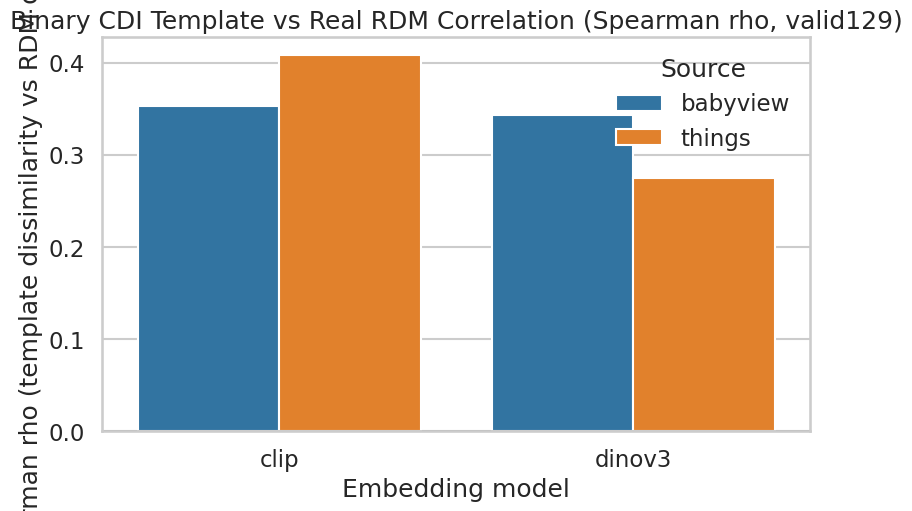

In [ ]:
# # Plot Pearson correlations (template dissimilarity vs real RDM)
# plot_col = 'spearman_rho_template_dissim_vs_rdm'
# plot_df = corr_df.copy()

# fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
# sns.barplot(data=plot_df, x='model', y=plot_col, hue='source', ax=ax)
# ax.axhline(0, color='black', linewidth=1)
# ax.set_title(f'Binary CDI Template vs Real RDM Correlation (Spearman rho, {OUTPUT_RUN_TAG})')
# ax.set_xlabel('Embedding model')
# ax.set_ylabel('Spearman rho (template dissimilarity vs RDM distance)')
# ax.legend(frameon=False, title='Source')

# fig_out = FIGURES_DIR / f'binary_template_vs_real_rdm_spearman_{OUTPUT_RUN_TAG}.png'
# save_figure_png_pdf(fig, fig_out, dpi=200)
# print(f'Saved: {fig_out} and {fig_out.with_suffix(".pdf")}')
# plt.show()

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/scatter_template_vs_rdm_babyview_clip_valid129.png and /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/scatter_template_vs_rdm_babyview_clip_valid129.pdf


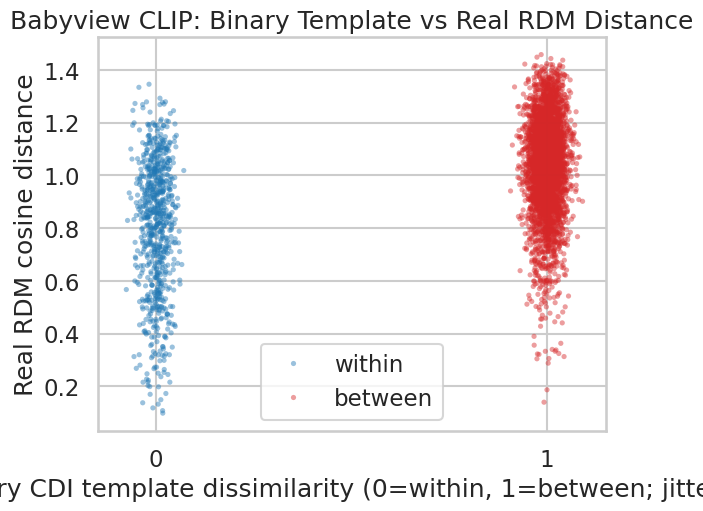

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/scatter_triangle_template_pairs_babyview_clip_valid129.png and /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/scatter_triangle_template_pairs_babyview_clip_valid129.pdf


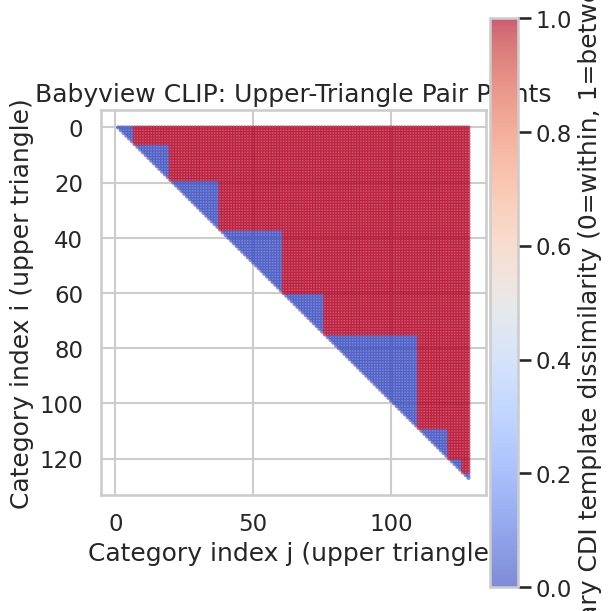

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/scatter_template_vs_rdm_things_clip_valid129.png and /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/scatter_template_vs_rdm_things_clip_valid129.pdf


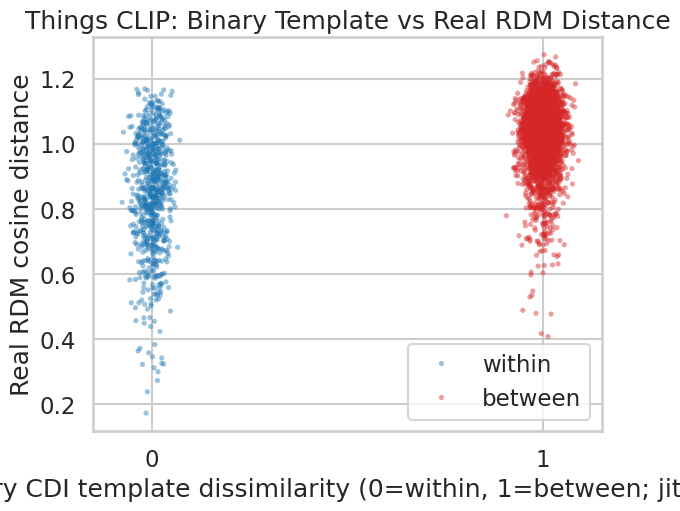

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/scatter_triangle_template_pairs_things_clip_valid129.png and /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/scatter_triangle_template_pairs_things_clip_valid129.pdf


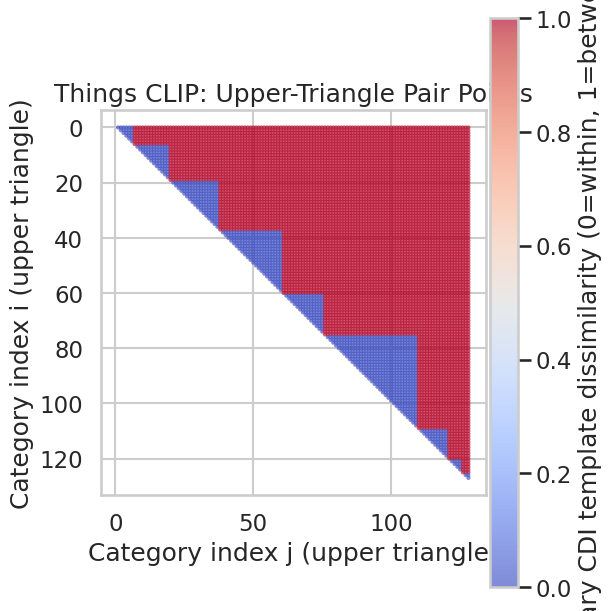

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/scatter_template_vs_rdm_babyview_dinov3_valid129.png and /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/scatter_template_vs_rdm_babyview_dinov3_valid129.pdf


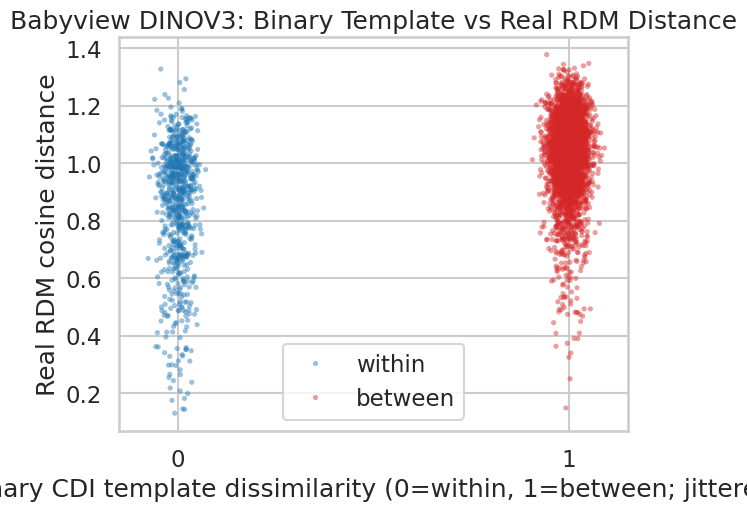

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/scatter_triangle_template_pairs_babyview_dinov3_valid129.png and /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/scatter_triangle_template_pairs_babyview_dinov3_valid129.pdf


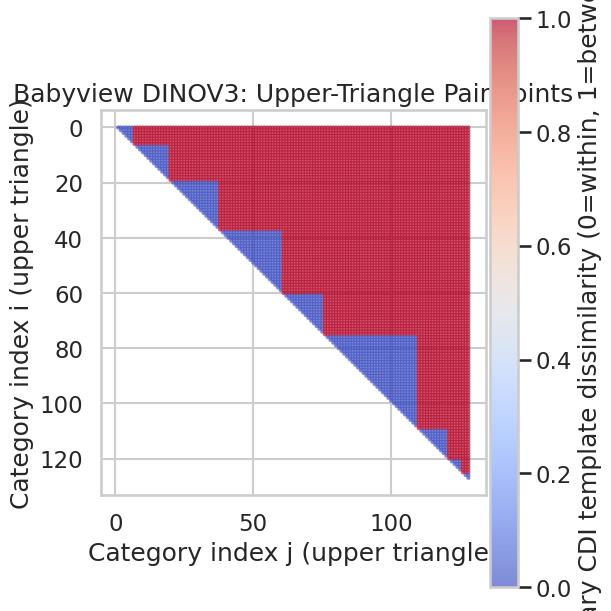

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/scatter_template_vs_rdm_things_dinov3_valid129.png and /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/scatter_template_vs_rdm_things_dinov3_valid129.pdf


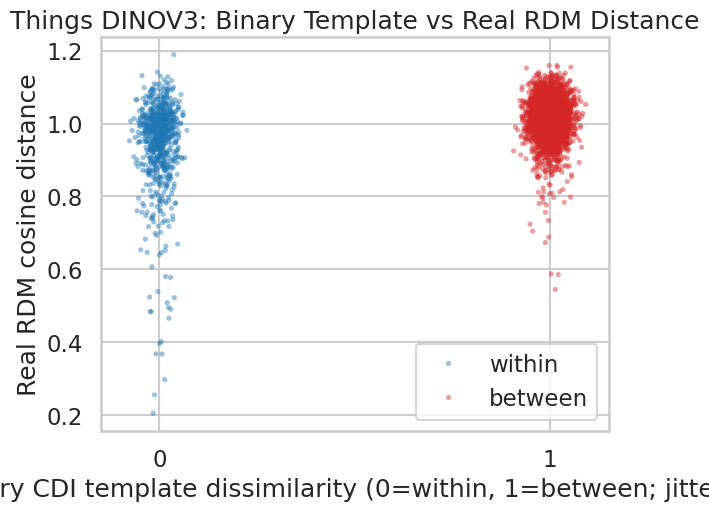

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/scatter_triangle_template_pairs_things_dinov3_valid129.png and /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/main_results_valid129s_04302026/figures/scatter_triangle_template_pairs_things_dinov3_valid129.pdf


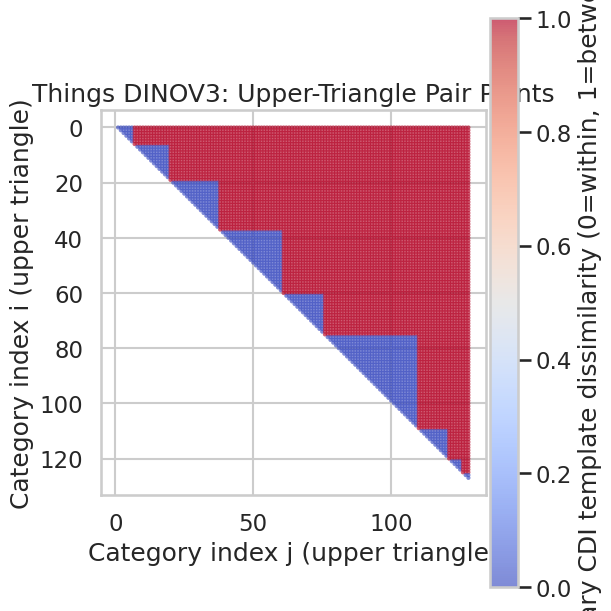

In [ ]:
# # Optional: pairwise scatter for each model/source
# for model in ['clip', 'dinov3']:
#     cats, sems, bv_emb, th_emb, _, _ = paired_subset_for_model(model)
#     template_sim = build_binary_cdi_template_rdm(sems, diagonal_value=np.nan)
#     # Consistent dissimilarity convention: within=0, between=1.
#     template_dis = 1.0 - template_sim

#     for source, emb in [('babyview', bv_emb), ('things', th_emb)]:
#         rdm = compute_rdm(emb)

#         # Use the same paired upper-triangle mask as correlation stats.
#         iu = np.triu_indices_from(template_dis, k=1)
#         x_raw = template_dis[iu]
#         y_raw = rdm[iu]
#         mask = np.isfinite(x_raw) & np.isfinite(y_raw)
#         x = x_raw[mask]
#         y = y_raw[mask]

#         # Subsample for plotting readability on larger category sets.
#         max_points = 5000
#         if len(x) > max_points:
#             rng = np.random.default_rng(2026)
#             idx = rng.choice(len(x), size=max_points, replace=False)
#             x_plot = x[idx]
#             y_plot = y[idx]
#         else:
#             x_plot = x
#             y_plot = y

#         # Color-code points by CDI pair type while plotting binary vs real distance.
#         pair_label = np.where(x_plot == 0.0, 'within', 'between')

#         # Small jitter on x improves visibility because x is binary (0 or 1).
#         rng_j = np.random.default_rng(2026)
#         x_jitter = x_plot + rng_j.normal(0.0, 0.025, size=len(x_plot))

#         fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
#         sns.scatterplot(
#             x=x_jitter,
#             y=y_plot,
#             hue=pair_label,
#             hue_order=['within', 'between'],
#             palette={'within': '#1f77b4', 'between': '#d62728'},
#             s=14,
#             alpha=0.45,
#             linewidth=0,
#             ax=ax,
#         )
#         ax.set_title(f'{source.title()} {model.upper()}: Binary Template vs Real RDM Distance')
#         ax.set_xlabel('Binary CDI template dissimilarity (0=within, 1=between; jittered)')
#         ax.set_ylabel('Real RDM cosine distance')
#         ax.set_xticks([0, 1])
#         ax.set_xlim(-0.15, 1.15)

#         out = FIGURES_DIR / f'scatter_template_vs_rdm_{source}_{model}_{OUTPUT_RUN_TAG}.png'
#         save_figure_png_pdf(fig, out, dpi=200)
#         print(f'Saved: {out} and {out.with_suffix(".pdf")}')
#         plt.show()

#         # NEW: point cloud on upper-triangle coordinates (j, i), colored by t_dis.
#         tri_i = iu[0][mask]
#         tri_j = iu[1][mask]
#         fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
#         sc = ax.scatter(
#             tri_j,
#             tri_i,
#             c=x,
#             cmap='coolwarm',
#             vmin=0,
#             vmax=1,
#             s=9,
#             alpha=0.65,
#             linewidths=0,
#         )
#         ax.set_title(f'{source.title()} {model.upper()}: Upper-Triangle Pair Points')
#         ax.set_xlabel('Category index j (upper triangle)')
#         ax.set_ylabel('Category index i (upper triangle)')
#         ax.set_aspect('equal', adjustable='box')
#         ax.invert_yaxis()
#         cbar = fig.colorbar(sc, ax=ax, pad=0.01)
#         cbar.set_label('Binary CDI template dissimilarity (0=within, 1=between)')

#         tri_out = FIGURES_DIR / f'scatter_triangle_template_pairs_{source}_{model}_{OUTPUT_RUN_TAG}.png'
#         save_figure_png_pdf(fig, tri_out, dpi=200)
#         print(f'Saved: {tri_out} and {tri_out.with_suffix(".pdf")}')
#         plt.show()